In [57]:

import sys
import pandas as pd
import numpy as np
import torch
import importlib
import json
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
from tqdm import tqdm
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, VPacker, HPacker, DrawingArea
from matplotlib.patches import Rectangle

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    auc
)

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing")
DATA_DIR = PROJECT_DIR / "data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"
RESULT_DIR = PROJECT_DIR / "testing_results"

sys.path.append(str(PROJECT_DIR))

import models.tf_to_tg as tf_to_tg_module
import models.tf_to_dna as tf_to_dna_module
from scripts.train_tf_to_tg_model import TFTGEdgeBagDataset, collate_tftg_edge_bags
import scripts.build_tf_to_tg_train_data as tf_tg_data_builder
import plotting_utils
import stat_utils
import utils
import warnings
import config

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

warnings.filterwarnings(
    "ignore",
    message="You are using `torch.load` with `weights_only=False`.*",
    category=FutureWarning,
)

In [2]:
OWN_MODEL_METHOD = "TF-TG Model (own test set)"
CROSS_MODEL_METHOD = "TF-TG Model (cross-trained)"

TFTG_MODEL_METHODS = [
    OWN_MODEL_METHOD,
    CROSS_MODEL_METHOD,
]

method_display_name_map = {
    OWN_MODEL_METHOD: "TF-TG Own",
    CROSS_MODEL_METHOD: "TF-TG Cross",
}

## Formatting Dictionaries

In [3]:
sample_order = [
    "E7.5_rep1",
    "E8.5_rep1",
    "buffer_1",
    "buffer_2",
    "sample_1",
    "hepatocytes_1",
    "hepatocytes_3",
]

sample_rename_map = {
    "E7.5_rep1": "mESC-1",
    "E8.5_rep1": "mESC-2",
    "buffer_1": "Macrophage-1",
    "buffer_2": "Macrophage-2",
    "sample_1": "K562",
    "hepatocytes_1": "Hepatocytes-1",
    "hepatocytes_3": "Hepatocytes-3",

    OWN_MODEL_METHOD: "TF-TG Model\n(Own)",
    CROSS_MODEL_METHOD: "TF-TG Model\n(Cross)",
}

sample_color_map = {
    "E7.5_rep1": "#4195df",
    "E8.5_rep1": "#86C7E7",
    "buffer_1": "#EF767A",
    "buffer_2": "#F9C60D",
    "sample_1": "#EF9CFA",
    "hepatocytes_1": "#82EC32",
    "hepatocytes_3": "#F98637",
}

method_color_dict = {
    OWN_MODEL_METHOD: "#4195df",
    CROSS_MODEL_METHOD: "#86C7E7",
    "LINGER": "#EF767A",
    "CellOracle": "#F9C60D",
    "Pando": "#EF9CFA",
    "SCENIC+": "#82EC32",
    "FigR": "#FDA7BB",
    "GRaNIE": "#F98637",
}

## Paths

In [8]:
tf_tg_input_cache_dir = DATA_DIR / "tf_tg_training_cache"

score_label_save_dir = RESULT_DIR / "model_generalizability" / "labeled_grns"
score_label_save_dir.mkdir(parents=True, exist_ok=True)

eval_metric_result_dir = RESULT_DIR / "evaluation_metrics"
eval_metric_result_dir.mkdir(exist_ok=True)

boxplot_dir = eval_metric_result_dir / "model_vs_other_method_boxplots"
boxplot_dir.mkdir(exist_ok=True)

all_evaluation_plot_dir = PROJECT_DIR / "plots" / "model_vs_test_set_evaluation_figs"
all_evaluation_plot_dir.mkdir(exist_ok=True)

roc_plot_dir = PROJECT_DIR / "plots" / "roc_curves"
roc_plot_dir.mkdir(parents=True, exist_ok=True)

auprc_plot_dir = RESULT_DIR / "auprc_plots"
auprc_plot_dir.mkdir(parents=True, exist_ok=True)

rank_plot_dir = PROJECT_DIR / "plots" / "rank_plots"
rank_plot_dir.mkdir(parents=True, exist_ok=True)

## Load the latest model checkpoints for each sample

In [5]:
tf_tg_model_checkpoints = {
    "mESC": {
        "E7.5_rep1": CHKPT_DIR / "mESC" / "E7.5_rep1" / "tf_tg_train_E7.5_rep1_3675131" / "epoch_11_best_model.ckpt",
        # "E7.5_rep1": utils.find_latest_checkpoint(CHKPT_DIR, "mESC", "E7.5_rep1"),
        "E7.5_rep2": utils.find_latest_checkpoint(CHKPT_DIR, "mESC", "E7.5_rep2"),
        "E8.5_rep1": utils.find_latest_checkpoint(CHKPT_DIR, "mESC", "E8.5_rep1", training_number="3691937"),
        "E8.5_rep2": utils.find_latest_checkpoint(CHKPT_DIR, "mESC", "E8.5_rep2", training_number="3691937"),
    },
    "iPSC": {
        "WT_D13_rep1": utils.find_latest_checkpoint(CHKPT_DIR, "iPSC", "WT_D13_rep1"),
    },
    "Macrophage": {
        "buffer_1": utils.find_latest_checkpoint(CHKPT_DIR, "Macrophage", "buffer_1", training_number="3685893"),
        "buffer_2": utils.find_latest_checkpoint(CHKPT_DIR, "Macrophage", "buffer_2", training_number="3713132"),
        "buffer_3": utils.find_latest_checkpoint(CHKPT_DIR, "Macrophage", "buffer_3"),
        "buffer_4": utils.find_latest_checkpoint(CHKPT_DIR, "Macrophage", "buffer_4"),
    },
    "K562": {
        "sample_1": utils.find_latest_checkpoint(CHKPT_DIR, "K562", "sample_1", training_number="3692409"),
    },
    "mouse_liver": {
        "liver_1": utils.find_latest_checkpoint(CHKPT_DIR, "mouse_liver", "liver_1"),
        "liver_3": utils.find_latest_checkpoint(CHKPT_DIR, "mouse_liver", "liver_3")
    },
    "mouse_hepatocytes": {
        "hepatocytes_1": utils.find_latest_checkpoint(CHKPT_DIR, "mouse_hepatocytes", "hepatocytes_1"),
        "hepatocytes_3": utils.find_latest_checkpoint(CHKPT_DIR, "mouse_hepatocytes", "hepatocytes_3"),
    }
}

INFO - Latest checkpoint for mESC E7.5_rep2: Job 3696113 Epoch 76
INFO - Latest checkpoint for mESC E8.5_rep1: Job 3691937 Epoch 42
WARNING - No checkpoint directories found for mESC E8.5_rep2 in /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/checkpoints/mESC/E8.5_rep2
INFO - Latest checkpoint for iPSC WT_D13_rep1: Job 3709598 Epoch 52
INFO - Latest checkpoint for Macrophage buffer_1: Job 3685893 Epoch 152
INFO - Latest checkpoint for Macrophage buffer_2: Job 3713132 Epoch 46
INFO - Latest checkpoint for Macrophage buffer_3: Job 3704579 Epoch 52
INFO - Latest checkpoint for Macrophage buffer_4: Job 3696147 Epoch 209
INFO - Latest checkpoint for K562 sample_1: Job 3692409 Epoch 63
INFO - Latest checkpoint for mouse_liver liver_1: Job 3708415 Epoch 42
INFO - Latest checkpoint for mouse_liver liver_3: Job 3708657 Epoch 48
INFO - Latest checkpoint for mouse_hepatocytes hepatocytes_1: Job 3709466 Epoch 33
INFO - Latest checkpoint f

## Functions

In [ ]:
def run_prediction_vs_test_set(
    tf_tg_model_checkpoints: dict,
    model_cell_type: str,
    model_training_sample: str,
    test_set_cell_type: str,
    evaluation_sample: str,
    dataset_split_type: str = "test",
    subset_size: int | None = None,
    show_progress_bar: bool = True,
    compile_model: bool = True,
    ):
    
    tf_tg_model_chkpt = tf_tg_model_checkpoints[model_cell_type][model_training_sample]
    tf_dna_model_chkpt = config.tf_dna_model_checkpoints[model_cell_type]
    
    if tf_tg_model_chkpt is None:
        logging.warning(f"Skipping evaluation for {model_cell_type} {model_training_sample} → {test_set_cell_type} {evaluation_sample} due to missing TF-TG checkpoint")
        return None

    cell_type_cache_dir = DATA_DIR / f"{test_set_cell_type}_cache"

    # print(f"Loading cached dataset with subset size: {subset_size}")
    data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = utils.load_training_cache_dataset(
        sample_name=evaluation_sample,
        cell_type_cache_dir=cell_type_cache_dir,
        split_type=dataset_split_type,
        subset_size=subset_size
        )
    
    tf_tg_model = utils.load_tf_tg_regulation_model(
        tf_dna_model_chkpt, 
        tf_tg_model_chkpt, 
        tf_embeddings_tensor, 
        tf_mask_tensor,
        compile_model=compile_model
        )

    # print("Moving model to device")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = tf_tg_model.model
    model = model.to(device)

    criterion = torch.nn.BCEWithLogitsLoss()
    score_threshold = 0.5
    pooling_mode = "lse"
    pooling_temperature = 1.0

    model.eval()

    total_loss = 0.0
    n_edges = 0

    all_scores = []
    all_labels = []
    plot_data = {}

    # print(f"Evaluating on {dataset_split_type} set")
    with torch.inference_mode():
        for batch in tqdm(data_loader, desc="Evaluating", ncols=100, disable=not show_progress_bar):
            
            batch = tf_to_tg_module.move_batch_to_device(batch, device)

            labels = batch["label"]
            cell_mask = batch["cell_mask"]
            E, C = cell_mask.shape

            edge_logits, _ = model.forward(
                tf_embedding=batch["tf_embedding"],
                tf_mask=batch["tf_mask"],
                peak_sequences=batch["peak_sequences"],
                peak_accessibility=batch["peak_accessibility"],
                peak_distance=batch["peak_distance"],
                tf_expression=batch["tf_expression"],
                tg_expression=batch["tg_expression"],
                peak_mask=batch.get("peak_mask", None),
                cell_mask=cell_mask,
                pooling_mode=pooling_mode,
                pooling_temperature=pooling_temperature,
            )

            loss = criterion(edge_logits, labels)

            total_loss += loss.item() * E
            n_edges += E

            scores = torch.sigmoid(edge_logits)

            all_scores.append(scores.detach().cpu().numpy().ravel())
            all_labels.append(labels.detach().cpu().numpy().ravel())

    all_scores_flat = np.concatenate(all_scores)
    all_labels_flat = np.concatenate(all_labels)

    metrics = stat_utils.compute_binary_classification_metrics(
        labels=all_labels_flat,
        scores=all_scores_flat,
        score_threshold=score_threshold,
        random_state=42,
    )

    metrics["Model"] = model_training_sample
    metrics["Test Set"] = evaluation_sample

    metric_df = pd.DataFrame([metrics])

    col_order = [
        "Model", 
        "Test Set", 
        "auroc", 
        "auprc", 
        "accuracy", 
        "precision", 
        "early_precision", 
        "recall", 
        "f1", 
        "rand_auroc", 
        "rand_auprc",
        "n_edges",
        "n_pos",
        "n_neg",
        "score_threshold"
        ]

    metric_df = metric_df[col_order]
    
    title = f"{model_cell_type} {model_training_sample} Model → {test_set_cell_type} {evaluation_sample} Test Set"
    
    plot_data = [all_labels_flat, all_scores_flat]
    
    return {
        "metric_df": metric_df,
        "plot_data": plot_data,
        "title": title
    }
    
def generate_model_predictions(
    model, 
    data_loader, 
    device, 
    tf_idx_to_name, 
    tg_idx_to_name,
    compile_model=False,
    ):
    pooling_mode = "lse"
    pooling_temperature = 1.0

    model = model.to(device)
    model.eval()
    
    if compile_model and device.type == "cuda":
        model = torch.compile(model, mode="reduce-overhead")

    tf_indices_list = []
    tg_indices_list = []
    all_scores = []

    with torch.inference_mode():
        for batch in tqdm(data_loader, desc="Evaluating", ncols=100):
            tf_indices = batch["tf_idx"].detach().cpu().numpy().ravel()
            tg_indices = batch["tg_idx"].detach().cpu().numpy().ravel()

            batch = tf_to_tg_module.move_batch_to_device(batch, device)

            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
                edge_logits, _ = model(
                    tf_embedding=batch["tf_embedding"],
                    tf_mask=batch["tf_mask"],
                    peak_sequences=batch["peak_sequences"],
                    peak_accessibility=batch["peak_accessibility"],
                    peak_distance=batch["peak_distance"],
                    tf_expression=batch["tf_expression"],
                    tg_expression=batch["tg_expression"],
                    peak_mask=batch.get("peak_mask", None),
                    cell_mask=batch["cell_mask"],
                    pooling_mode=pooling_mode,
                    pooling_temperature=pooling_temperature,
                )

            scores = torch.sigmoid(edge_logits.float())

            tf_indices_list.append(tf_indices)
            tg_indices_list.append(tg_indices)
            all_scores.append(scores.detach().cpu().numpy().ravel())

    all_tf_indices_flat = np.concatenate(tf_indices_list)
    all_tg_indices_flat = np.concatenate(tg_indices_list)
    all_scores_flat = np.concatenate(all_scores)

    tf_names = [tf_idx_to_name[int(idx)].upper() for idx in all_tf_indices_flat]
    tg_names = [tg_idx_to_name[int(idx)].upper() for idx in all_tg_indices_flat]

    prediction_df = pd.DataFrame({
        "Source": tf_names,
        "Target": tg_names,
        "Score": all_scores_flat,
    })

    prediction_df = (
        prediction_df.groupby(["Source", "Target"], as_index=False)["Score"]
        .median()
    )

    return prediction_df

def create_tf_tg_index_to_name_mappings(metadata):
    tf_idx_to_name = {idx: name for name, idx in metadata["tf_name_to_idx"].items()}
    tg_idx_to_name = {idx: name for name, idx in metadata["tg_id_to_idx"].items()}
    return tf_idx_to_name, tg_idx_to_name

def create_tf_tg_label_df(tftg_inputs_test):
    # Create the TF-TG label DataFrame
    tftg_inputs_test.keys()
    test_tf_input = tftg_inputs_test["tf_name"]
    test_tg_input = tftg_inputs_test["tg_name"]
    test_labels = tftg_inputs_test["label"]

    # create TF-TG label DataFrame
    tf_tg_label_df = pd.DataFrame({
        "Source": test_tf_input,
        "Target": test_tg_input,
        "Label": test_labels,
    })

    tf_tg_label_df = tf_tg_label_df.drop_duplicates(["Source", "Target"])

    gt_df: pd.DataFrame = tf_tg_label_df[tf_tg_label_df["Label"] == 1] 
    gt_tfs = set(gt_df["Source"].str.upper().unique()) 
    gt_targets = set(gt_df["Target"].str.upper().unique()) 
    gt_pairs = set(gt_df["Source"].str.upper() + "\t" + gt_df["Target"].str.upper())
    
    return tf_tg_label_df, gt_pairs, gt_tfs, gt_targets

def load_and_standardize_method(name: str, info: dict) -> pd.DataFrame:
    """
    Load a GRN CSV and rename tf_col/target_col/score_col -> Source/Target/Score.
    Extra columns are preserved.
    """
    if info["path"].suffix == ".tsv":
        sep = "\t"
    elif info["path"].suffix == ".csv":
        sep = ","
    
    df = pd.read_csv(info["path"], sep=sep, header=0, index_col=None)

    tf_col     = info["tf_col"]
    target_col = info["target_col"]
    score_col  = info["score_col"]

    sample_rename_map = {
        tf_col: "Source",
        target_col: "Target",
        score_col: "Score",
    }

    missing = [c for c in sample_rename_map if c not in df.columns]
    if missing:
        raise ValueError(f"[{name}] Missing expected columns: {missing}. Got: {list(df.columns)}")

    df = df.rename(columns=sample_rename_map)

    df = df[["Source", "Target", "Score"]]
    df["Source"] = df["Source"].astype(str).str.upper()
    df["Target"] = df["Target"].astype(str).str.upper()
    
    df["Score"] = np.abs(df["Score"])

    return df

def precision_at_k(y_true, y_score, k=10_000):
    """Compute precision at k for binary classification/ranking problems."""
    # Sort the scores in descending order and get their corresponding true labels
    top_k_indices = np.argsort(y_score)[::-1][:k]
    top_k_labels = np.array(y_true)[top_k_indices]
    
    # Calculate precision in top K
    return np.sum(top_k_labels == 1) / k

def compute_metrics(method_name: str, sample_name: str, df: pd.DataFrame, gt_pairs: set, score_threshold: float):            
    labels = [1 if pair in gt_pairs else 0 for pair in df["Source"] + "\t" + df["Target"]]
    scores = df["Score"].tolist()
    
    labels = np.asarray(labels).astype(int).ravel()
    scores = np.asarray(scores).astype(float).ravel()

    preds = (scores >= score_threshold).astype(int)

    early_precision = precision_at_k(labels, scores, k=10_000)
    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)

    if len(np.unique(labels)) < 2:
        auroc = np.nan
    else:
        auroc = roc_auc_score(labels, scores)

    return pd.DataFrame([{
        "method_name": method_name,
        "sample_name": sample_name,
        "auroc": auroc,
        "early_precision": early_precision,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "n_edges": len(labels),
        "n_pos": int(labels.sum()),
        "n_neg": int((labels == 0).sum()),
        "score_threshold": score_threshold,
    }])

def load_auprc_grns_all_methods(sample_list=None):
    auprc_all_method_dfs = {}

    if sample_list is not None:
        sample_list = set(sample_list)

    method_name_from_safe = {
        "celloracle": "CellOracle",
        "scenic": "SCENIC+",
        "linger": "LINGER",
        "pando": "Pando",
        "figr": "FigR",
        "tf-tg model (own test set)": OWN_MODEL_METHOD,
        "tf-tg model (cross-trained)": CROSS_MODEL_METHOD,
    }

    for cell_type_dir in (RESULT_DIR / "labeled_auprc_grns").iterdir():
        if not cell_type_dir.is_dir():
            continue

        for sample_dir in cell_type_dir.iterdir():
            if not sample_dir.is_dir():
                continue

            if sample_list is not None and sample_dir.name not in sample_list:
                continue

            # Create nested dict before assigning methods
            auprc_all_method_dfs.setdefault(sample_dir.name, {})

            for method_file in sample_dir.glob("*.tsv"):
                method_name_safe = method_file.stem

                if method_name_safe not in method_name_from_safe:
                    logging.warning(
                        f"Unrecognized method name: {method_name_safe}. Using as-is."
                    )

                method_name = method_name_from_safe.get(method_name_safe, method_name_safe)

                auprc_df = pd.read_csv(method_file, sep="\t")
                auprc_all_method_dfs[sample_dir.name][method_name] = auprc_df

    return auprc_all_method_dfs

def load_generalizability_df(model_sample_name, test_set_sample_name, sample_size=10000):
    score_label_save_dir = RESULT_DIR / "model_generalizability" / "labeled_grns"
    
    score_label_file = (
        score_label_save_dir
        / f"{model_sample_name}_model_vs_{test_set_sample_name}_grn_{sample_size}.csv"
    )
    
    if not score_label_file.exists():
        logging.warning(f"Score-label file not found for {model_sample_name} vs {test_set_sample_name}. Skipping.")
        return None
    
    score_label_df = pd.read_csv(score_label_file)

    return score_label_df

---

## Run model vs test set

In [ ]:
all_comparison_df_list = []

evaluations = [
    ("mESC", "E7.5_rep1", "mESC", "E7.5_rep1"),
    # ("mESC", "E8.5_rep1", "mESC", "E8.5_rep1"),
    
    # ("mouse_hepatocytes", "hepatocytes_1", "mouse_hepatocytes", "hepatocytes_1"),
    # ("mouse_hepatocytes", "hepatocytes_3", "mouse_hepatocytes", "hepatocytes_3"),
    
    # ("Macrophage", "buffer_1", "Macrophage", "buffer_1"),
    # ("Macrophage", "buffer_2", "Macrophage", "buffer_2"),
    
    # ("K562", "sample_1", "K562", "sample_1")

]

all_plot_data = {}

subset_size = 10_000
# for model_cell_type, model_training_sample, test_set_cell_type, evaluation_sample in tqdm(evaluations, desc="Evaluating all model vs test set combinations", ncols=100):
for model_cell_type, model_training_sample, test_set_cell_type, evaluation_sample in evaluations:
    logging.info(f"Evaluating {model_cell_type} {model_training_sample} Model → {test_set_cell_type} {evaluation_sample} Test Set")

    dataset_split_type = "test"
        
    comparison_result = run_prediction_vs_test_set(
        tf_tg_model_checkpoints=tf_tg_model_checkpoints,
        model_cell_type=model_cell_type,
        model_training_sample=model_training_sample,
        test_set_cell_type=test_set_cell_type,
        evaluation_sample=evaluation_sample,
        dataset_split_type=dataset_split_type,
        subset_size=subset_size,
        show_progress_bar=True,
        compile_model=True
    )
        
    metric_df = comparison_result["metric_df"]
    plot_data = comparison_result["plot_data"]
    
    all_labels_flat = plot_data[0]
    all_scores_flat = plot_data[1]
    
    title = comparison_result["title"]
    
    all_plot_data[title] = (all_labels_flat, all_scores_flat)
    
    all_comparison_df_list.append(metric_df)
    
full_comparison_df = pd.concat(all_comparison_df_list, ignore_index=True)

display(full_comparison_df.T)

In [ ]:
for title in all_plot_data.keys():
    all_labels_flat = all_plot_data[title][0]
    all_scores_flat = all_plot_data[title][1]

    histogram_fig = plotting_utils.plot_score_histograms(
        labels=all_labels_flat,
        scores=all_scores_flat,
        n_bins=50,
        y_log=False,
        panel_kind="kde",
        density=False,
        title = title
    )
    histogram_fig.show()
    
    model_sample, test_set_sample = title.split(" → ")
    model_sample = model_sample.split("Model")[0].split()[1].strip()
    test_set_sample = test_set_sample.split("Test Set")[0].split()[1].strip()
    title = f"{model_sample} Model\n{test_set_sample} Test Set"

auroc_auprc_fig = plotting_utils.plot_auroc_auprc(
    labels=all_labels_flat,
    scores=all_scores_flat,
    title = title,
    plot_type = "roc"
)
auroc_auprc_fig.show()

---

## Generalizability

### Load all generalizability comparison metrics

In [ ]:
all_comparison_dfs = []
individual_comparison_dir = RESULT_DIR / "model_generalizability" / "comparison_metric_files"
for comparison_file in individual_comparison_dir.glob("*.csv"):
    comparison_df = pd.read_csv(comparison_file)
    all_comparison_dfs.append(comparison_df)
    
generalizability_df = pd.concat(all_comparison_dfs, ignore_index=True)
generalizability_df.to_csv(RESULT_DIR / "model_generalizability" / "model_generalizability_results.csv", index=False)
display(generalizability_df.T)

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
Model,hepatocytes_1,buffer_1,E7.5_rep1,E7.5_rep1,E7.5_rep1,E8.5_rep1,buffer_2,hepatocytes_1,buffer_1,hepatocytes_3,...,hepatocytes_1,hepatocytes_1,E8.5_rep1,E7.5_rep1,hepatocytes_1,E8.5_rep1,buffer_2,hepatocytes_3,buffer_2,buffer_2
Test Set,E8.5_rep1,E8.5_rep1,buffer_2,hepatocytes_3,E8.5_rep1,E7.5_rep1,buffer_1,hepatocytes_3,hepatocytes_3,buffer_1,...,buffer_2,hepatocytes_1,buffer_2,E7.5_rep1,E7.5_rep1,hepatocytes_3,buffer_2,E8.5_rep1,hepatocytes_3,hepatocytes_1
auroc,0.566533,0.511315,0.653382,0.701157,0.650239,0.606784,0.673499,0.764845,0.590907,0.446266,...,0.44499,0.7982,0.592626,0.747641,0.586535,0.663527,0.766358,0.573692,0.572945,0.601139
auprc,0.335498,0.313222,0.419443,0.558924,0.437106,0.536465,0.511385,0.689727,0.489506,0.292305,...,0.316127,0.736505,0.393461,0.680137,0.465853,0.523966,0.640929,0.337234,0.495095,0.49858
accuracy,0.5766,0.6335,0.65036,0.6239,0.6833,0.593768,0.6702,0.7272,0.5909,0.5924,...,0.629152,0.7333,0.655762,0.691304,0.523188,0.5891,0.743097,0.6129,0.5976,0.5897
precision,0.342636,0.314041,0.412898,0.571381,0.45977,0.520776,0.492303,0.68325,0.52982,0.259194,...,0.339555,0.696424,0.444918,0.65942,0.460506,0.525773,0.682875,0.345785,0.595291,0.540444
early_precision,0.342636,0.314041,0.412898,0.571381,0.45977,0.520776,0.492303,0.68325,0.52982,0.259194,...,0.339555,0.696424,0.444918,0.65942,0.460506,0.525773,0.682875,0.345785,0.595291,0.540444
recall,0.462807,0.19724,0.170859,0.413209,0.376977,0.326616,0.462319,0.651645,0.218169,0.136573,...,0.145092,0.645446,0.224233,0.537526,0.834607,0.206724,0.396319,0.339616,0.126609,0.144969
f1,0.393757,0.242299,0.241701,0.47959,0.414278,0.401452,0.47684,0.667073,0.309069,0.178888,...,0.20331,0.669967,0.298185,0.592266,0.593526,0.296765,0.501553,0.342673,0.208808,0.228614
rand_auroc,0.497723,0.507632,0.513065,0.498813,0.498051,0.503418,0.50553,0.494707,0.496861,0.505307,...,0.494277,0.499651,0.502311,0.501261,0.504682,0.504436,0.502529,0.496878,0.499219,0.506456


In [ ]:
org_dict = {
    "E7.5_rep1": ("mouse", "mESC"),
    "E8.5_rep1": ("mouse", "mESC"),
    "buffer_1": ("human", "Macrophage"),
    "buffer_2": ("human", "Macrophage"),
    "hepatocytes_1": ("mouse", "mouse_hepatocytes"),
    "hepatocytes_3": ("mouse", "mouse_hepatocytes"),
    "liver_1": ("mouse", "mouse_liver"),
    "liver_3": ("mouse", "mouse_liver"),
    "sample_1": ("human", "K562"),
    "WT_D13_rep1": ("human", "iPSC")
}

celltype_order = ["mESC", "mouse_hepatocytes", "Macrophage", "K562", "iPSC", "mouse_liver"]

generalizability_df["Model Organism"] = generalizability_df["Model"].map(lambda x: org_dict.get(x, ("Unknown", "Unknown"))[0])
generalizability_df["Model Cell Type"] = generalizability_df["Model"].map(lambda x: org_dict.get(x, ("Unknown", "Unknown"))[1])
generalizability_df["Test Set Organism"] = generalizability_df["Test Set"].map(lambda x: org_dict.get(x, ("Unknown", "Unknown"))[0])
generalizability_df["Test Set Cell Type"] = generalizability_df["Test Set"].map(lambda x: org_dict.get(x, ("Unknown", "Unknown"))[1])

generalizability_df["auprc_lift"] = generalizability_df["auprc"] - generalizability_df["rand_auprc"]

own_test_set = generalizability_df[generalizability_df["Model"] == generalizability_df["Test Set"]]
same_cell_type = generalizability_df[(generalizability_df["Model Cell Type"] == generalizability_df["Test Set Cell Type"]) & (generalizability_df["Model"] != generalizability_df["Test Set"])]
different_cell_type = generalizability_df[(generalizability_df["Model Cell Type"] != generalizability_df["Test Set Cell Type"]) & (generalizability_df["Model Organism"] == generalizability_df["Test Set Organism"])]
different_organism = generalizability_df[generalizability_df["Model Organism"] != generalizability_df["Test Set Organism"]]

def agg_results(df):
    df_grouped = df.groupby(["Model Cell Type"]).agg(
        auroc_mean=("auroc", "mean"),
        auprc_mean=("auprc", "mean"),
        auprc_lift_mean=("auprc_lift", "mean"),
        accuracy_mean=("accuracy", "mean"),
        precision_mean=("precision", "mean"),
        early_precision_mean=("early_precision", "mean"),
        recall_mean=("recall", "mean"),
        f1_mean=("f1", "mean")
    ).reset_index()
    
    df_grouped = df_grouped.sort_values("Model Cell Type", key=lambda x: x.map({celltype: i for i, celltype in enumerate(celltype_order)}))
    
    # Round to 3 decimal places for better readability
    df_grouped = df_grouped.round(3)
    
    return df_grouped

own_test_set_group = agg_results(own_test_set)
same_cell_type_group = agg_results(same_cell_type)
different_cell_type_group = agg_results(different_cell_type)
different_organism_group = agg_results(different_organism)

own_test_set_group.to_csv(RESULT_DIR / "model_generalizability" / "own_test_set_metrics.csv", index=False)
same_cell_type_group.to_csv(RESULT_DIR / "model_generalizability" / "different_sample_metrics.csv", index=False)
different_cell_type_group.to_csv(RESULT_DIR / "model_generalizability" / "different_cell_type_metrics.csv", index=False)
different_organism_group.to_csv(RESULT_DIR / "model_generalizability" / "different_organism_metrics.csv", index=False)

### Generalizability summary figure

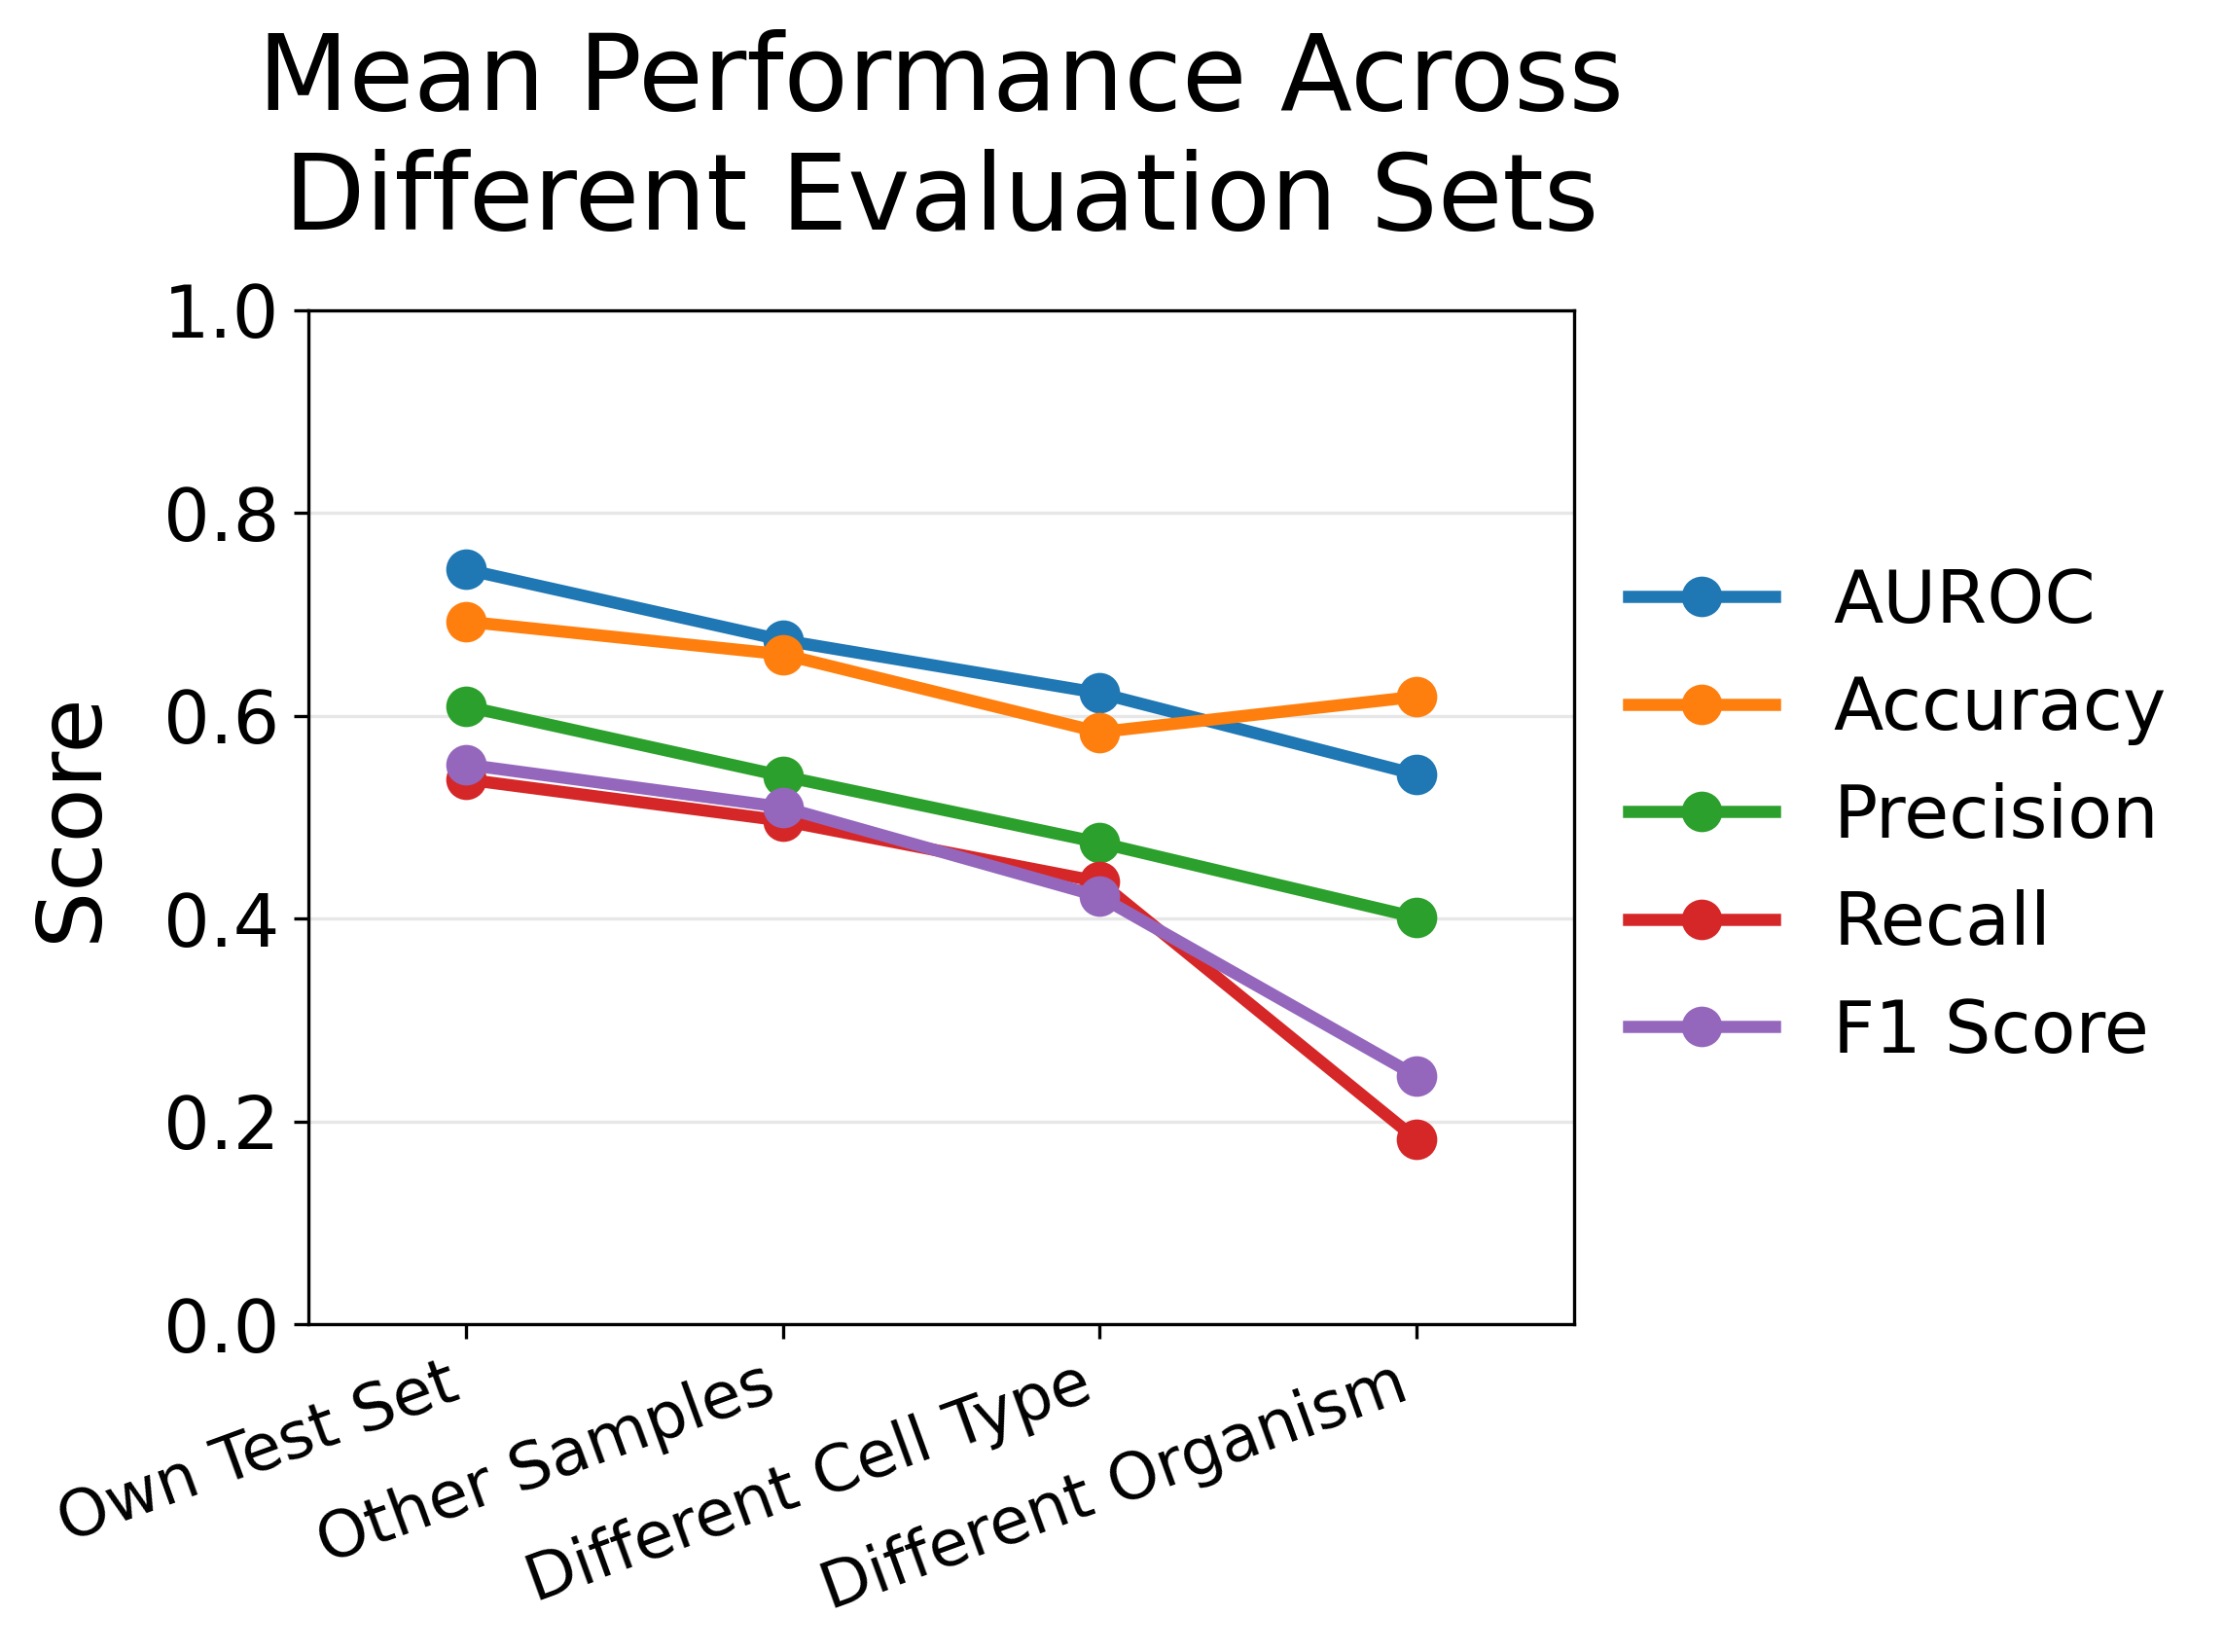

In [ ]:
evaluation_order = [
    "Own Test Set",
    "Other Samples",
    "Different Cell Type",
    "Different Organism"
]

evaluation_sets = {
    "Own Test Set": own_test_set_group,
    "Other Samples": same_cell_type_group,
    "Different Cell Type": different_cell_type_group,
    "Different Organism": different_organism_group
}

metrics = {
    "auroc_mean": "AUROC",
    # "auprc_mean": "AUPRC",
    "accuracy_mean": "Accuracy",
    "precision_mean": "Precision",
    "recall_mean": "Recall",
    "f1_mean": "F1 Score"
}

summary_rows = []

for eval_name in evaluation_order:
    df = evaluation_sets[eval_name]
    row = {"Evaluation Set": eval_name}

    for metric_col in metrics:
        row[metric_col] = df[metric_col].mean()

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

x = np.arange(len(evaluation_order))

# Poster-friendly global settings
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 26,
    "axes.labelsize": 22,
    "xtick.labelsize": 16,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

for metric_col, label in metrics.items():
    ax.plot(
        x,
        summary_df[metric_col],
        marker="o",
        markersize=9,
        linewidth=3,
        label=label
    )

ax.set_xticks(x)
ax.set_xticklabels(evaluation_order, rotation=20, ha="right")

# Pad x-axis so labels/points do not hit the edge
ax.set_xlim(-0.5, len(evaluation_order) - 0.5)

ax.set_title("Mean Performance Across\nDifferent Evaluation Sets", pad=20)
# ax.set_xlabel("Evaluation Set", labelpad=12)
ax.set_ylabel("Score", labelpad=12)
ax.set_ylim(0, 1)

ax.legend(
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0
)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
models_to_plot = [
    "E7.5_rep1",
    "E8.5_rep1",
    "buffer_1",
    "buffer_2",
    "sample_1",
    "hepatocytes_1",
    "hepatocytes_3",
]

### Own test set ROC - one graph per sample

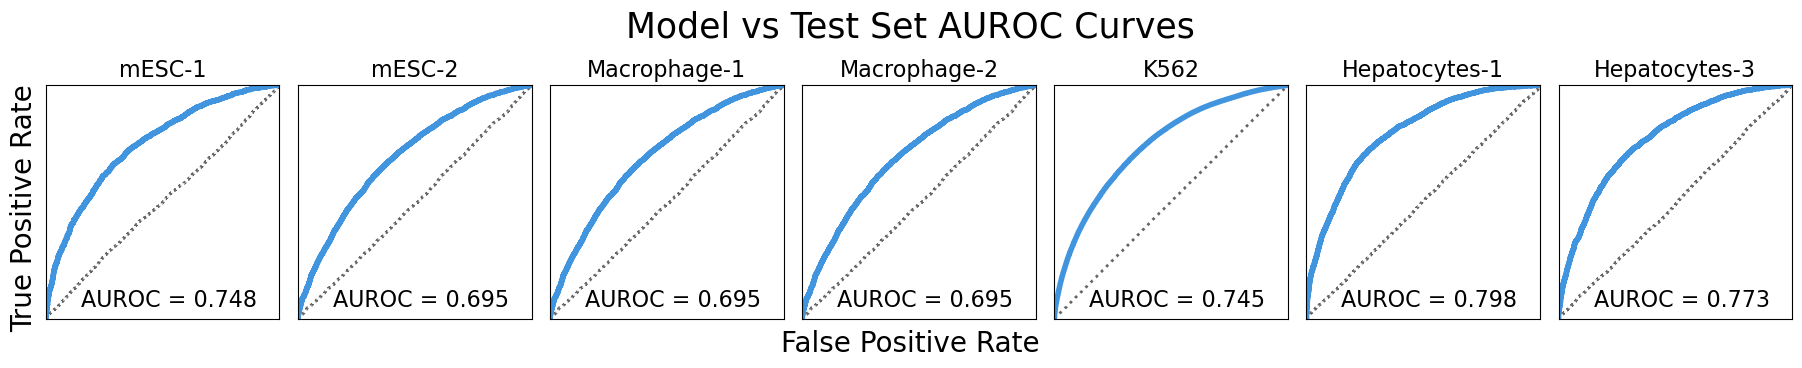

In [ ]:
fig, ax = plt.subplots(1, 7, figsize=(18, 6))

for i, sample_name in enumerate(models_to_plot):

    ax[i].set_aspect("equal")
    
    score_label_df = load_generalizability_df(sample_name, sample_name)
    scores = score_label_df["Score"].values
    labels = score_label_df["Label"].values
        
    rng = np.random.default_rng(42)
    rand_scores = rng.permutation(scores)

    fpr, tpr, thresholds = roc_curve(labels, scores)
    rand_fpr, rand_tpr, rand_thresholds = roc_curve(labels, rand_scores)
    auroc = roc_auc_score(labels, scores)

    ax[i].plot(
        fpr,
        tpr,
        lw=4,
        color="#4195df",
        label=f"AUROC = {auroc:.3f}",
        zorder=2,
    )

    ax[i].plot(
        rand_fpr,
        rand_tpr,
        color="black",
        linestyle=":",
        lw=2,
        alpha=0.6,
        zorder=1,
    )

    ax[i].set_title(
        sample_rename_map.get(sample_name, sample_name),
        fontsize=16,
    )

    ax[i].set_xlim(0, 1)
    ax[i].set_ylim(0, 1)

    ax[i].text(
        0.15,
        0.05,
        f"AUROC = {auroc:.3f}",
        transform=ax[i].transAxes,
        fontsize=16,
        bbox=dict(facecolor="none", edgecolor="none"),
    )

    ax[i].tick_params(bottom=False, left=False)
    ax[i].set_xticklabels([])
    ax[i].set_yticklabels([])

fig.suptitle("Model vs Test Set AUROC Curves", fontsize=25, y=0.75)

fig.text(
    0.5,
    0.18,
    "False Positive Rate",
    ha="center",
    fontsize=20,
)

fig.text(
    0.00,
    0.42,
    "True Positive Rate",
    va="center",
    rotation="vertical",
    fontsize=20,
)

fig.subplots_adjust(
    left=0.02,
    right=0.99,
    bottom=0.01,
    top=0.85,
    wspace=0.08,
)

fig.savefig(all_evaluation_plot_dir / f"models_vs_own_test_set_auroc.png", dpi=300, bbox_inches="tight")

plt.show()

### Own test set ROC - All samples one fig

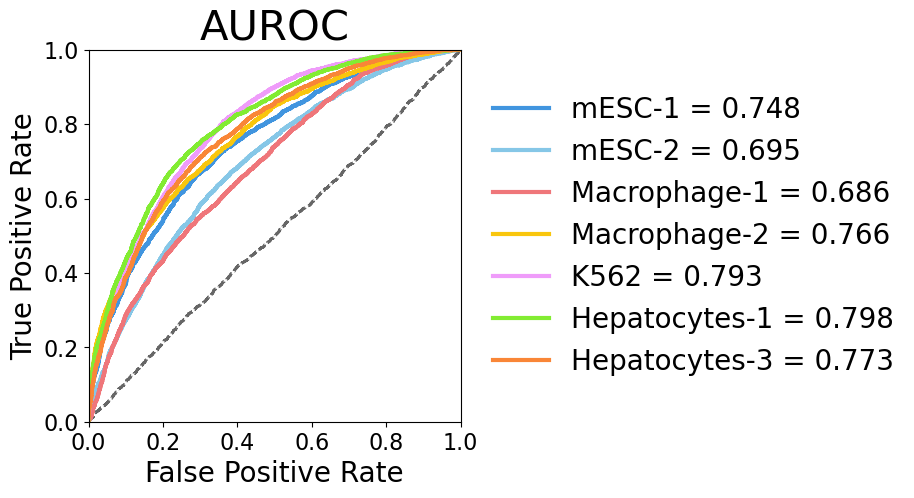

In [65]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.set_aspect("equal")

rng = np.random.default_rng(42)
random_curve_plotted = False

for sample_name in models_to_plot:

    score_label_df = load_generalizability_df(sample_name, sample_name)
    scores = score_label_df["Score"].values
    labels = score_label_df["Label"].values

    labels = pd.to_numeric(pd.Series(labels), errors="coerce").to_numpy()
    scores = pd.to_numeric(pd.Series(scores), errors="coerce").to_numpy()

    valid_mask = ~np.isnan(labels) & ~np.isnan(scores)
    labels = labels[valid_mask].astype(int)
    scores = scores[valid_mask]

    fpr, tpr, _ = roc_curve(labels, scores)
    auroc = roc_auc_score(labels, scores)

    ax.plot(
        fpr,
        tpr,
        lw=3,
        color=sample_color_map.get(sample_name, None),
        label=f"{sample_rename_map.get(sample_name, sample_name)} = {auroc:.3f}",
    )

    # Plot one shuffled/random baseline only
    if not random_curve_plotted:
        rand_scores = rng.permutation(scores)
        rand_fpr, rand_tpr, _ = roc_curve(labels, rand_scores)

        ax.plot(
            rand_fpr,
            rand_tpr,
            color="black",
            linestyle="--",
            lw=2,
            alpha=0.6,
            zorder=1,
        )

        random_curve_plotted = True


ax.set_title("AUROC", fontsize=30)
ax.set_xlabel("False Positive Rate", fontsize=20)
ax.set_ylabel("True Positive Rate", fontsize=20)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.tick_params(axis="both", labelsize=16)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=20,
)

fig.subplots_adjust(
    left=0.10,
    right=0.72,
    bottom=0.10,
    top=0.90,
)

fig.savefig(
    all_evaluation_plot_dir / "models_vs_own_test_set_auroc_combined.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Own test set PRC - All samples one fig

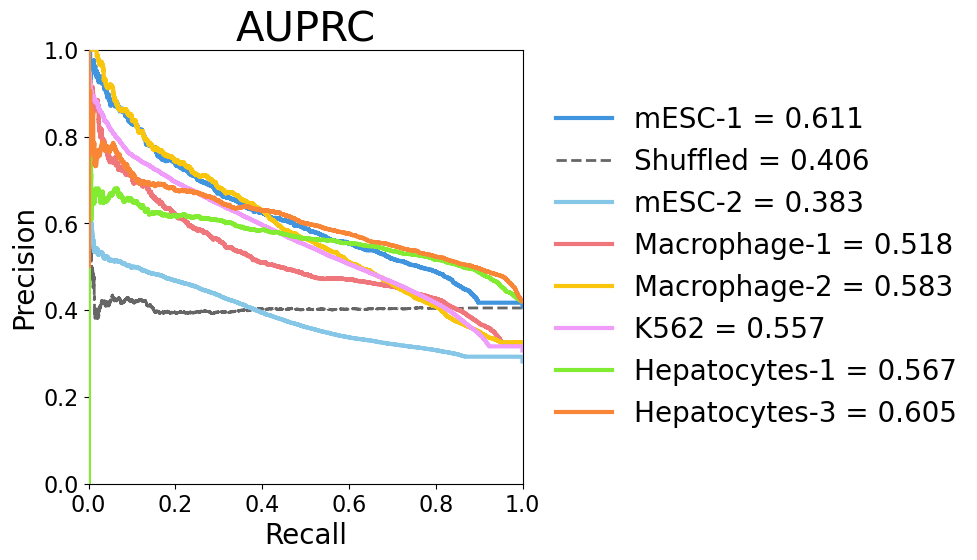

In [66]:
tf_tg_method_name = OWN_MODEL_METHOD

fig, ax = plt.subplots(figsize=(7, 6))

rng = np.random.default_rng(42)
random_curve_plotted = False

cell_type_method_auprc = {
    "sample_name": [],
    "method": [],
    "auprc": [],
    "rand_auprc": [],
}

auprc_all_method_dfs = load_auprc_grns_all_methods(sample_list=models_to_plot)

for sample_name in models_to_plot:
    if sample_name not in auprc_all_method_dfs:
        logging.warning(
            f"Sample {sample_name} was not found in labeled AUPRC files. Skipping."
        )
        continue

    if tf_tg_method_name not in auprc_all_method_dfs[sample_name]:
        logging.warning(
            f"Method {tf_tg_method_name!r} not found for sample {sample_name}. "
            f"Available methods: {sorted(auprc_all_method_dfs[sample_name].keys())}"
        )
        continue

    auprc_df = auprc_all_method_dfs[sample_name][tf_tg_method_name].copy()

    labels = pd.to_numeric(auprc_df["_in_gt"], errors="coerce").to_numpy()
    scores = pd.to_numeric(auprc_df["Score"], errors="coerce").to_numpy()

    valid_mask = ~np.isnan(labels) & ~np.isnan(scores)
    labels = labels[valid_mask].astype(int)
    scores = scores[valid_mask]

    if len(np.unique(labels)) < 2:
        logging.warning(
            f"Sample {sample_name} has only one label class after filtering. Skipping."
        )
        continue

    precision, recall, _ = precision_recall_curve(labels, scores)
    auprc = average_precision_score(labels, scores)

    rand_scores = rng.permutation(scores)
    rand_precision, rand_recall, _ = precision_recall_curve(labels, rand_scores)
    rand_auprc = average_precision_score(labels, rand_scores)

    cell_type_method_auprc["sample_name"].append(sample_name)
    cell_type_method_auprc["method"].append(tf_tg_method_name)
    cell_type_method_auprc["auprc"].append(auprc)
    cell_type_method_auprc["rand_auprc"].append(rand_auprc)

    # sklearn returns recall in descending order, so reverse for cleaner left-to-right plotting
    plot_recall = recall[::-1]
    plot_precision = precision[::-1]

    ax.step(
        plot_recall,
        plot_precision,
        where="post",
        lw=3,
        color=sample_color_map.get(sample_name, None),
        label=f"{sample_rename_map.get(sample_name, sample_name)} = {auprc:.3f}",
        zorder=3,
    )

    if not random_curve_plotted:
        ax.step(
            rand_recall[::-1],
            rand_precision[::-1],
            where="post",
            color="black",
            linestyle="--",
            lw=2,
            alpha=0.6,
            label=f"Shuffled = {rand_auprc:.3f}",
            zorder=1,
        )

        random_curve_plotted = True

ax.set_title("AUPRC", fontsize=30)
ax.set_xlabel("Recall", fontsize=20)
ax.set_ylabel("Precision", fontsize=20)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal", adjustable="box")

ax.tick_params(axis="both", labelsize=16)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=20,
)

fig.subplots_adjust(
    left=0.10,
    right=0.72,
    bottom=0.10,
    top=0.90,
)

fig.savefig(
    all_evaluation_plot_dir / "models_vs_own_test_set_auprc_combined.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

cell_type_method_auprc = pd.DataFrame(cell_type_method_auprc)

### Own test set AUPRC Lift - All samples in one fig

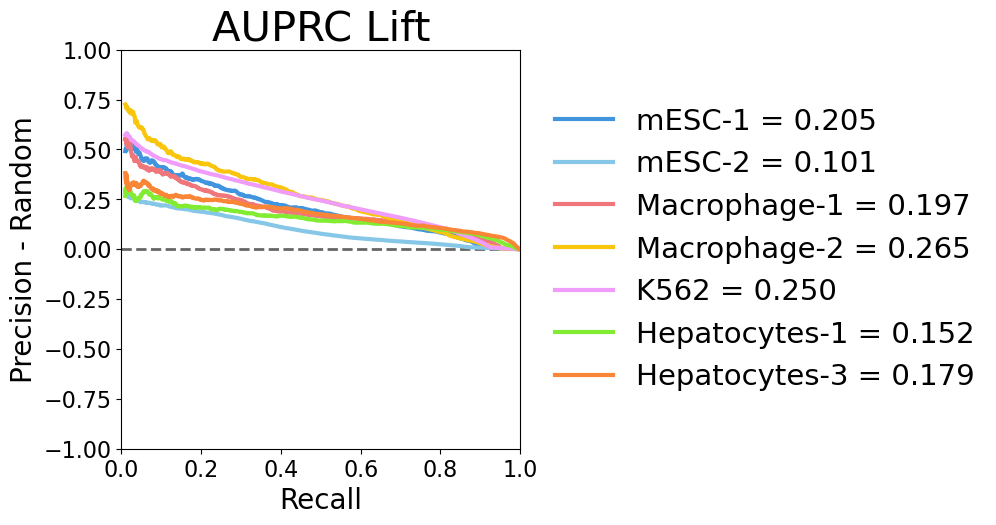

In [58]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.set_box_aspect(1)

rng = np.random.default_rng(42)

cell_type_method_auprc_lift = {
    "sample_name": [],
    "method": [],
    "auprc": [],
    "rand_auprc": [],
    "auprc_lift": [],
    "curve_lift_auc": [],
}

recall_grid = np.linspace(0, 1, 1000)

for sample_name in models_to_plot:

    if sample_name not in auprc_all_method_dfs:
        logging.warning(f"Sample {sample_name} not found in auprc_all_method_dfs. Skipping.")
        continue

    if tf_tg_method_name not in auprc_all_method_dfs[sample_name]:
        logging.warning(
            f"Method {tf_tg_method_name} not found for sample {sample_name}. Skipping."
        )
        continue

    auprc_df = auprc_all_method_dfs[sample_name][tf_tg_method_name].copy()

    labels = pd.to_numeric(auprc_df["_in_gt"], errors="coerce").to_numpy()
    scores = pd.to_numeric(auprc_df["Score"], errors="coerce").to_numpy()

    valid_mask = ~np.isnan(labels) & ~np.isnan(scores)
    labels = labels[valid_mask].astype(int)
    scores = scores[valid_mask]

    if len(np.unique(labels)) < 2:
        logging.warning(
            f"Sample {sample_name} has only one label class after filtering. Skipping."
        )
        continue

    precision, recall, _ = precision_recall_curve(labels, scores)
    auprc = average_precision_score(labels, scores)

    rand_scores = rng.permutation(scores)
    rand_precision, rand_recall, _ = precision_recall_curve(labels, rand_scores)
    rand_auprc = average_precision_score(labels, rand_scores)

    # precision_recall_curve returns recall in descending order,
    # so reverse before interpolation.
    precision_interp = np.interp(
        recall_grid,
        recall[::-1],
        precision[::-1],
    )

    rand_precision_interp = np.interp(
        recall_grid,
        rand_recall[::-1],
        rand_precision[::-1],
    )

    precision_lift = precision_interp - rand_precision_interp

    auprc_lift = auprc - rand_auprc
    curve_lift_auc = auc(recall_grid, precision_lift)

    cell_type_method_auprc_lift["sample_name"].append(sample_name)
    cell_type_method_auprc_lift["method"].append(tf_tg_method_name)
    cell_type_method_auprc_lift["auprc"].append(auprc)
    cell_type_method_auprc_lift["rand_auprc"].append(rand_auprc)
    cell_type_method_auprc_lift["auprc_lift"].append(auprc_lift)
    cell_type_method_auprc_lift["curve_lift_auc"].append(curve_lift_auc)

    min_recall_to_plot = 0.01

    plot_mask = recall_grid >= min_recall_to_plot

    ax.plot(
        recall_grid[plot_mask],
        precision_lift[plot_mask],
        lw=3,
        color=sample_color_map.get(sample_name, None),
        label=(
            f"{sample_rename_map.get(sample_name, sample_name)} "
            f"= {auprc_lift:.3f}"
        ),
        zorder=3,
    )


ax.axhline(
    0,
    color="black",
    linestyle="--",
    lw=2,
    alpha=0.6,
    zorder=1,
)

ax.set_title("AUPRC Lift", fontsize=30)
ax.set_xlabel("Recall", fontsize=20)
ax.set_ylabel("Precision - Random", fontsize=20)

ax.set_xlim(0, 1)
ax.set_ylim(-1, 1)

ax.tick_params(axis="both", labelsize=16)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=21,
)

fig.subplots_adjust(
    left=0.15,
    right=0.72,
    bottom=0.12,
    top=0.90,
)

fig.savefig(
    all_evaluation_plot_dir / "models_vs_own_test_set_auprc_lift_combined.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

cell_type_method_auprc_lift = pd.DataFrame(cell_type_method_auprc_lift)

## Cross-trained model vs other inference methods

In [64]:
samples_to_run = [
    ("mESC", "E7.5_rep1", "mouse_hepatocytes", "hepatocytes_1"),
    ("mESC", "E8.5_rep1", "mouse_hepatocytes", "hepatocytes_1"),
    ("Macrophage", "buffer_1", "K562", "sample_1"),
    ("Macrophage", "buffer_2", "K562", "sample_1"),
    ("K562", "sample_1", "Macrophage", "buffer_1"),
    ("mouse_hepatocytes", "hepatocytes_1", "mESC", "E7.5_rep1"),
    ("mouse_hepatocytes", "hepatocytes_3", "mESC", "E7.5_rep1"),
]


def _is_binary_like(series):
    vals = pd.Series(series).dropna().unique()
    return len(vals) > 0 and set(vals).issubset({0, 1, 0.0, 1.0, True, False})


def standardize_prediction_score_label_df(df):
    """
    Makes cached/generated model prediction files consistent.

    Expected output:
        - Score column
        - _in_gt column when Source/Target are absent
    """
    df = df.copy()

    if "Score" not in df.columns and "score" in df.columns:
        df = df.rename(columns={"score": "Score"})

    if "_in_gt" not in df.columns:
        if "label" in df.columns:
            df["_in_gt"] = df["label"]
        elif "Label" in df.columns:
            df["_in_gt"] = df["Label"]

    # Handle accidentally reversed label/score columns.
    if "Score" in df.columns and "_in_gt" in df.columns:
        score_is_binary = _is_binary_like(df["Score"])
        label_is_binary = _is_binary_like(df["_in_gt"])

        if score_is_binary and not label_is_binary:
            old_score = df["Score"].copy()
            df["Score"] = df["_in_gt"]
            df["_in_gt"] = old_score

    if "_in_gt" in df.columns:
        df["_in_gt"] = df["_in_gt"].astype(int)

    return df


def load_or_generate_tftg_predictions(
    label_file,
    tf_dna_model_chkpt,
    tf_tg_model_chkpt,
    tf_embeddings_tensor,
    tf_mask_tensor,
    data_loader,
    device,
    tf_idx_to_name,
    tg_idx_to_name,
    compile_model=True,
):
    if label_file.exists():
        logging.info(f"    - Loading cached predictions from: {label_file.name}")
        prediction_df = pd.read_csv(label_file)
        return standardize_prediction_score_label_df(prediction_df)

    logging.info(f"    - Generating predictions and saving to: {label_file.name}")

    tf_tg_model = utils.load_tf_tg_regulation_model(
        tf_dna_model_chkpt,
        tf_tg_model_chkpt,
        tf_embeddings_tensor,
        tf_mask_tensor,
        compile_model=compile_model,
    )

    prediction_df = generate_model_predictions(
        tf_tg_model.model,
        data_loader,
        device,
        tf_idx_to_name,
        tg_idx_to_name,
    )

    prediction_df = standardize_prediction_score_label_df(prediction_df)

    label_file.parent.mkdir(parents=True, exist_ok=True)
    prediction_df.to_csv(label_file, index=False)

    return prediction_df

standardized_method_dfs = {}
label_by_method_dict = {}
score_by_method_dict = {}
metric_by_method_list = []
gt_by_sample_dict = {}

sample_list = [sample_name for _, sample_name, _, _ in samples_to_run]
auprc_all_method_dfs = load_auprc_grns_all_methods(sample_list=sample_list)

subset_size = 10_000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for model_cell_type, sample_name, cross_model_cell_type, cross_model_sample_name in samples_to_run:

    logging.info(
        f"Processing test sample: {sample_name} | "
        f"Test cell type: {model_cell_type} | "
        f"Cross-trained model: {cross_model_cell_type}/{cross_model_sample_name}"
    )

    cell_type_cache_dir = DATA_DIR / f"{model_cell_type}_cache"

    model_label_file = (
        score_label_save_dir
        / f"{sample_name}_model_vs_{sample_name}_grn_{subset_size}.csv"
    )

    cross_model_label_file = (
        score_label_save_dir
        / f"{cross_model_sample_name}_model_vs_{sample_name}_grn_{subset_size}.csv"
    )

    # Load cached test dataset for the evaluation/test sample.
    data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = utils.load_training_cache_dataset(
        sample_name=sample_name,
        cell_type_cache_dir=cell_type_cache_dir,
        split_type="test",
        subset_size=subset_size,
    )

    # Load full test labels / edge metadata.
    tftg_inputs_test = torch.load(
        cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "tftg_inputs_test.pt",
        weights_only=False,
    )

    tf_idx_to_name, tg_idx_to_name = create_tf_tg_index_to_name_mappings(metadata)

    test_set_tf_indices = list(tftg_inputs_test["tf_idx"].numpy())
    test_set_tg_indices = list(tftg_inputs_test["tg_idx"].numpy())

    tf_names = [tf_idx_to_name[int(idx)].upper() for idx in test_set_tf_indices]
    tg_names = [tg_idx_to_name[int(idx)].upper() for idx in test_set_tg_indices]

    # -----------------------------
    # Own-model predictions
    # -----------------------------
    own_tf_tg_model_chkpt = tf_tg_model_checkpoints[model_cell_type][sample_name]
    own_tf_dna_model_chkpt = config.tf_dna_model_checkpoints[model_cell_type]

    prediction_df = load_or_generate_tftg_predictions(
        label_file=model_label_file,
        tf_dna_model_chkpt=own_tf_dna_model_chkpt,
        tf_tg_model_chkpt=own_tf_tg_model_chkpt,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        data_loader=data_loader,
        device=device,
        tf_idx_to_name=tf_idx_to_name,
        tg_idx_to_name=tg_idx_to_name,
        compile_model=False,
    )

    # -----------------------------
    # Cross-trained model predictions
    # -----------------------------
    cross_tf_tg_model_chkpt = tf_tg_model_checkpoints[cross_model_cell_type][cross_model_sample_name]
    cross_tf_dna_model_chkpt = config.tf_dna_model_checkpoints[cross_model_cell_type]

    cross_model_prediction_df = load_or_generate_tftg_predictions(
        label_file=cross_model_label_file,
        tf_dna_model_chkpt=cross_tf_dna_model_chkpt,
        tf_tg_model_chkpt=cross_tf_tg_model_chkpt,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        data_loader=data_loader,
        device=device,
        tf_idx_to_name=tf_idx_to_name,
        tg_idx_to_name=tg_idx_to_name,
        compile_model=False,
    )

    # -----------------------------
    # Ground truth
    # -----------------------------
    tf_tg_label_df, gt_pairs, gt_tfs, gt_targets = create_tf_tg_label_df(tftg_inputs_test)

    gt_tfs = gt_tfs.intersection(set(tf_names))
    gt_targets = gt_targets.intersection(set(tg_names))

    gt_pairs = {
        pair
        for pair in gt_pairs
        if pair.split("\t")[0] in gt_tfs and pair.split("\t")[1] in gt_targets
    }

    gt_by_sample_dict[sample_name] = {
        "gt_pairs": gt_pairs,
        "gt_tfs": gt_tfs,
        "gt_targets": gt_targets,
        "test_cell_type": model_cell_type,
        "test_sample": sample_name,
    }

    # -----------------------------
    # Other method GRNs
    # -----------------------------
    OTHER_METHOD_MUON_DIR = Path(
        "/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/other_method_grns"
    )

    linger_path = (
        OTHER_METHOD_MUON_DIR
        / "LINGER_muon"
        / f"linger_{model_cell_type}_{sample_name}.tsv"
    )

    scenic_plus_path = (
        OTHER_METHOD_MUON_DIR
        / "SCENIC_muon"
        / f"scenicplus_{model_cell_type}_{sample_name}.tsv"
    )

    cell_oracle_path = (
        OTHER_METHOD_MUON_DIR
        / "CellOracle_muon"
        / f"celloracle_{model_cell_type}_{sample_name}.tsv"
    )

    pando_path = (
        OTHER_METHOD_MUON_DIR
        / "Pando_muon"
        / f"pando_{model_cell_type}_{sample_name}.tsv"
    )

    figr_path = (
        OTHER_METHOD_MUON_DIR
        / "FigR_muon"
        / f"figr_{model_cell_type}_{sample_name}.tsv"
    )

    method_info = {
        "SCENIC+": {
            "path": scenic_plus_path,
            "tf_col": "Source",
            "target_col": "Target",
            "score_col": "Score",
        },
        "LINGER": {
            "path": linger_path,
            "tf_col": "Source",
            "target_col": "Target",
            "score_col": "Score",
        },
        "CellOracle": {
            "path": cell_oracle_path,
            "tf_col": "Source",
            "target_col": "Target",
            "score_col": "Score",
        },
        "Pando": {
            "path": pando_path,
            "tf_col": "Source",
            "target_col": "Target",
            "score_col": "Score",
        },
        "FigR": {
            "path": figr_path,
            "tf_col": "Source",
            "target_col": "Target",
            "score_col": "Score",
        },
    }

    standardized_method_dfs[sample_name] = {}

    for method_name, info in method_info.items():
        df_std = load_and_standardize_method(method_name, info)

        mask = df_std["Source"].isin(gt_tfs) & df_std["Target"].isin(gt_targets)
        df_filtered = df_std.loc[mask].copy()

        standardized_method_dfs[sample_name][method_name] = df_filtered

    # Important:
    # Use stable method labels, not sample names.
    standardized_method_dfs[sample_name][OWN_MODEL_METHOD] = prediction_df
    standardized_method_dfs[sample_name][CROSS_MODEL_METHOD] = cross_model_prediction_df

    label_by_method_dict[sample_name] = {}
    score_by_method_dict[sample_name] = {}

    # -----------------------------
    # Metric computation
    # -----------------------------
    for method_name, df in standardized_method_dfs[sample_name].items():
        df = standardize_prediction_score_label_df(df)

        if "Source" in df.columns and "Target" in df.columns:
            labels = [
                1 if pair in gt_pairs else 0
                for pair in df["Source"] + "\t" + df["Target"]
            ]
        elif "_in_gt" in df.columns:
            labels = df["_in_gt"].astype(int).tolist()
        else:
            raise ValueError(
                f"{method_name} for {sample_name} has neither "
                "Source/Target columns nor an _in_gt label column."
            )

        scores = df["Score"].tolist()

        label_by_method_dict[sample_name][method_name] = labels
        score_by_method_dict[sample_name][method_name] = scores

        metrics_df = compute_metrics(
            method_name,
            sample_name,
            df,
            gt_pairs,
            score_threshold=0.5,
        )

        metrics_df["test_cell_type"] = model_cell_type
        metrics_df["test_sample"] = sample_name
        
        labeled_auprc_df = auprc_all_method_dfs[sample_name][method_name]
        metrics_df["auprc"] = average_precision_score(labeled_auprc_df["_in_gt"], labeled_auprc_df["Score"])

        if method_name == OWN_MODEL_METHOD:
            metrics_df["model_eval_type"] = "own_test_set"
            metrics_df["train_cell_type"] = model_cell_type
            metrics_df["train_sample"] = sample_name

        elif method_name == CROSS_MODEL_METHOD:
            metrics_df["model_eval_type"] = "cross_trained"
            metrics_df["train_cell_type"] = cross_model_cell_type
            metrics_df["train_sample"] = cross_model_sample_name

        else:
            metrics_df["model_eval_type"] = "external_method"
            metrics_df["train_cell_type"] = np.nan
            metrics_df["train_sample"] = np.nan

        metric_by_method_list.append(metrics_df)

        safe_method_name = (
            method_name
            .replace(" ", "_")
            .replace("/", "_")
            .replace("(", "")
            .replace(")", "")
        )

        sample_metric_df_path = (
            eval_metric_result_dir
            / model_cell_type
            / sample_name
            / f"{safe_method_name}_{sample_name}_metrics.csv"
        )

        sample_metric_df_path.parent.mkdir(parents=True, exist_ok=True)
        # metrics_df.to_csv(sample_metric_df_path, index=False)


full_metric_df = pd.concat(metric_by_method_list, ignore_index=True)

# Optional
# full_metric_df.to_csv(
#     eval_metric_result_dir / "full_method_comparison_metrics.csv",
#     index=False,
# )

INFO - Processing test sample: E7.5_rep1 | Test cell type: mESC | Cross-trained model: mouse_hepatocytes/hepatocytes_1
INFO -     - Loading cached predictions from: E7.5_rep1_model_vs_E7.5_rep1_grn_10000.csv
INFO -     - Loading cached predictions from: hepatocytes_1_model_vs_E7.5_rep1_grn_10000.csv
INFO - Processing test sample: E8.5_rep1 | Test cell type: mESC | Cross-trained model: mouse_hepatocytes/hepatocytes_1
INFO -     - Loading cached predictions from: E8.5_rep1_model_vs_E8.5_rep1_grn_10000.csv
INFO -     - Loading cached predictions from: hepatocytes_1_model_vs_E8.5_rep1_grn_10000.csv
INFO - Processing test sample: buffer_1 | Test cell type: Macrophage | Cross-trained model: K562/sample_1
INFO -     - Loading cached predictions from: buffer_1_model_vs_buffer_1_grn_10000.csv
INFO -     - Loading cached predictions from: sample_1_model_vs_buffer_1_grn_10000.csv
INFO - Processing test sample: buffer_2 | Test cell type: Macrophage | Cross-trained model: K562/sample_1
INFO -     -

### Metric performance by method boxplots

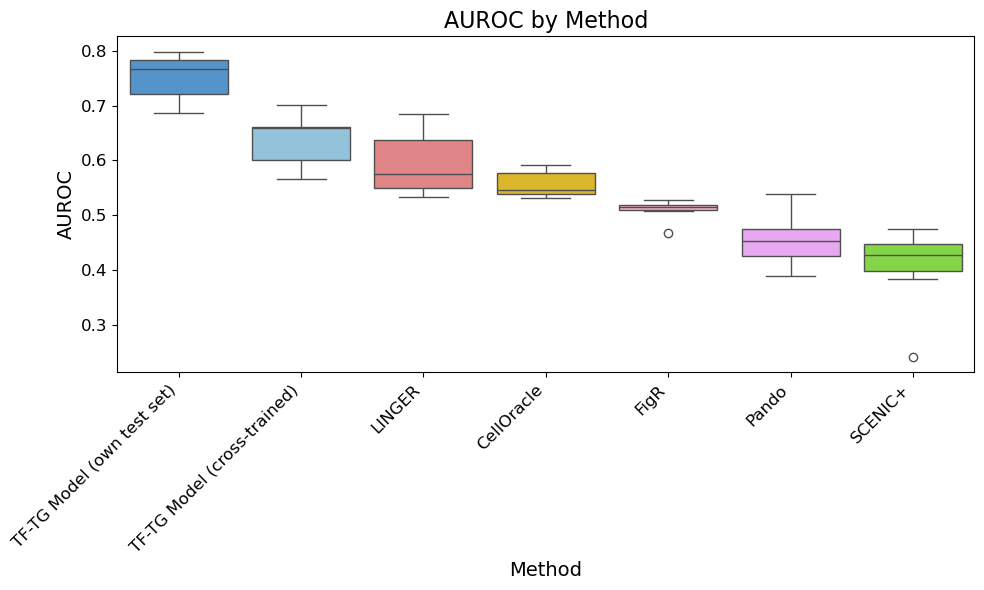

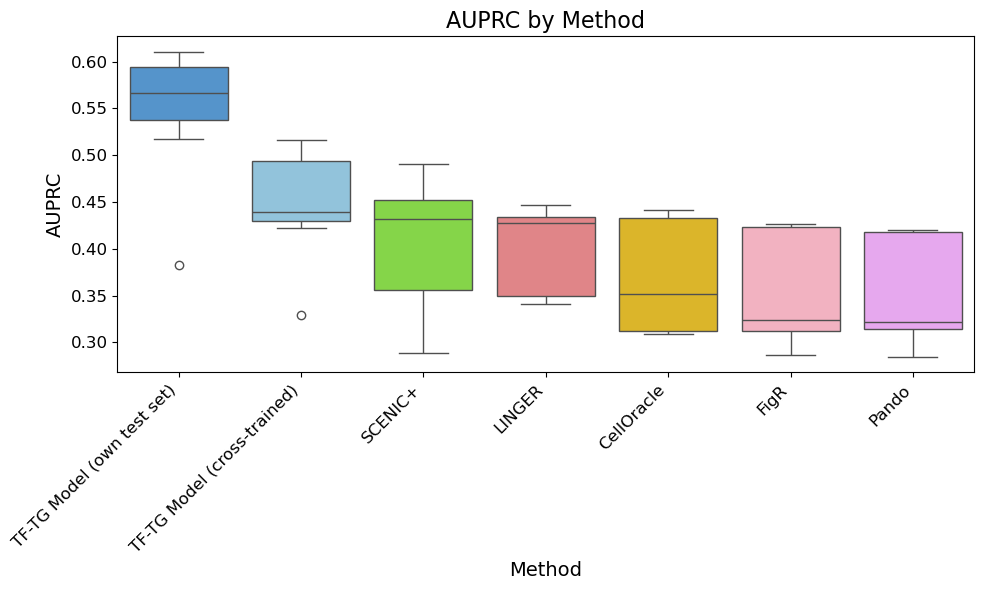

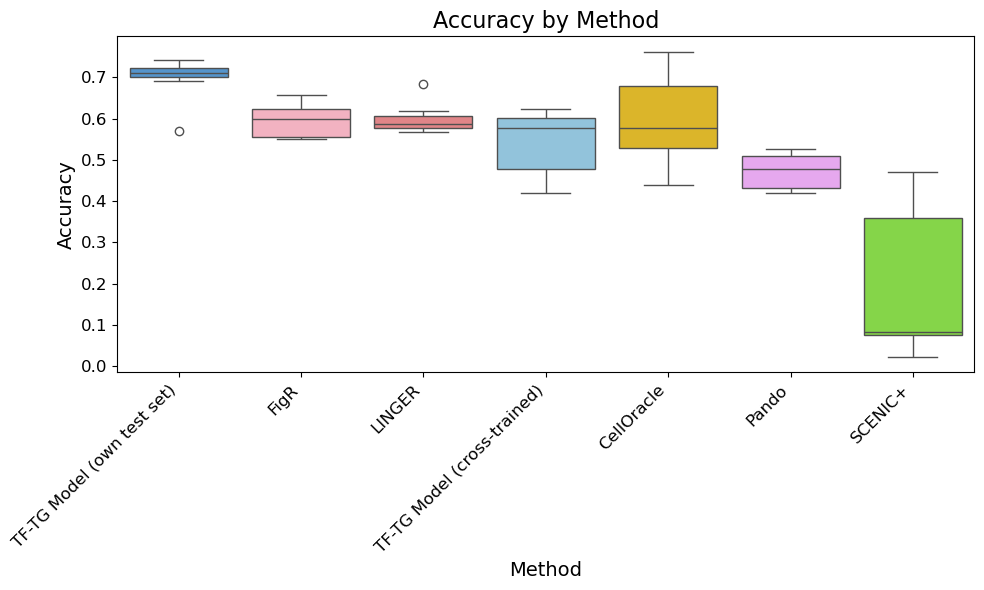

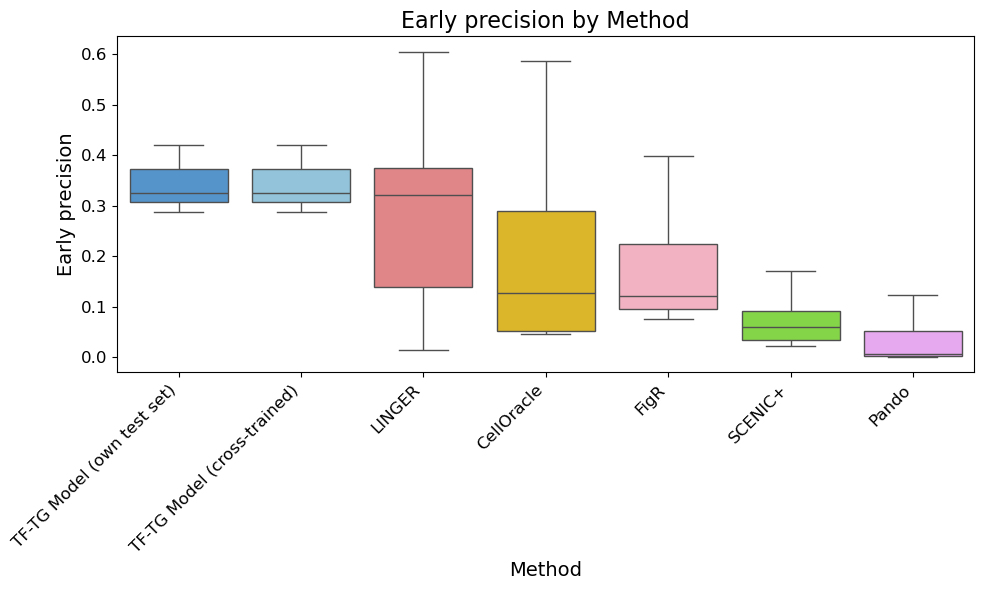

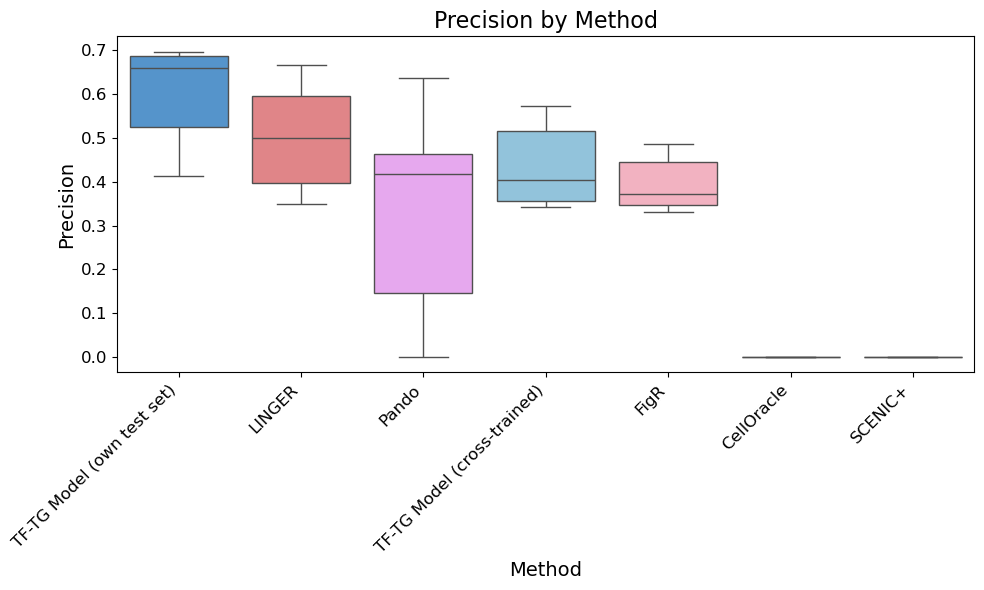

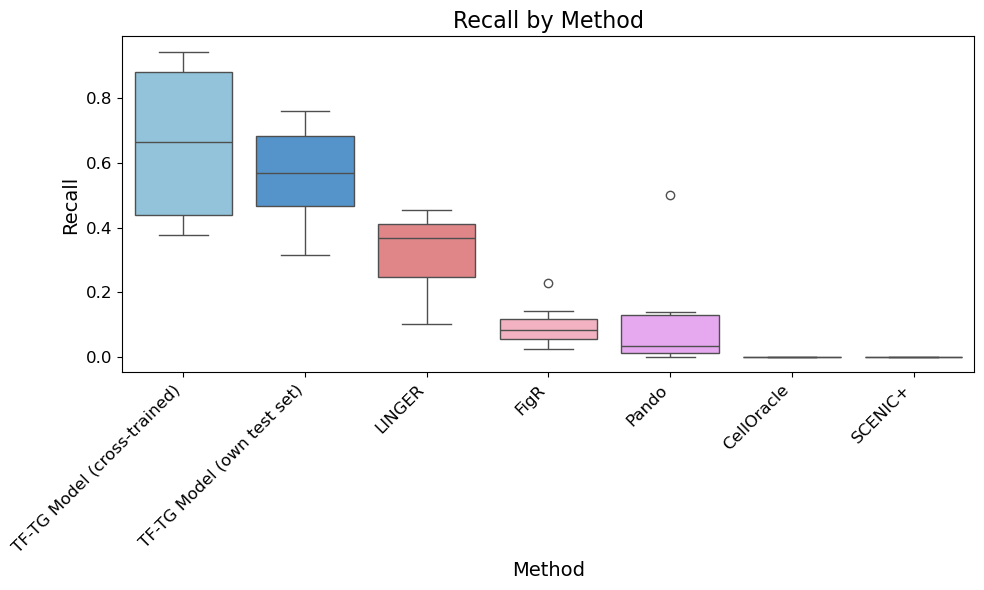

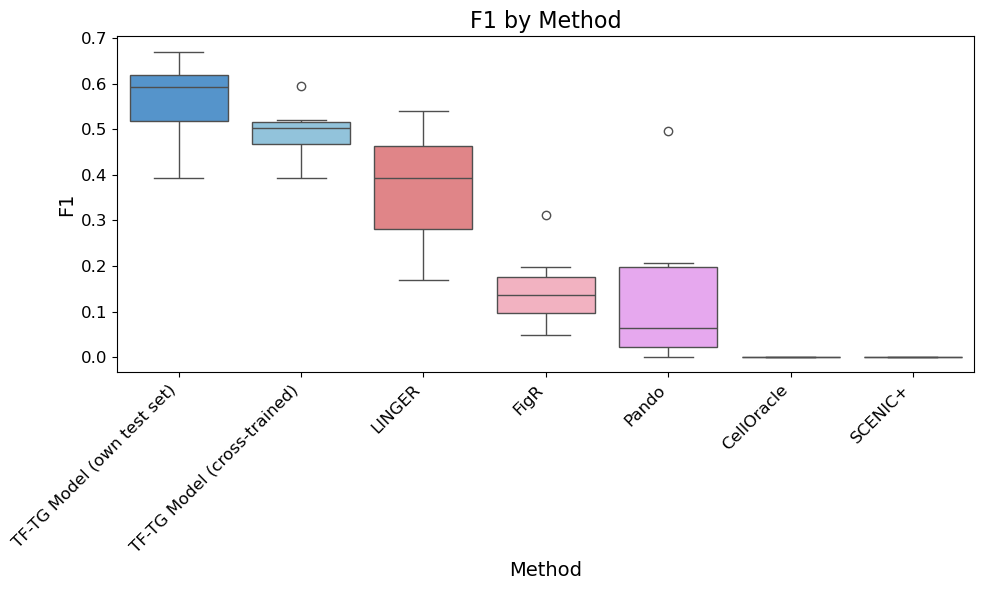

In [37]:
# Selected columns by method box and whisker plot
methods = ["auroc", "auprc", "accuracy", "early_precision", "precision", "recall", "f1"]

for selected_column in methods:
    metric_ordered_by_auroc = (
        full_metric_df
        .groupby("method_name")[selected_column]
        .median()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    sanitized_name = selected_column.replace("_", " ").lower()
    if sanitized_name in ["auroc", "auprc"]:
        sanitized_name = sanitized_name.upper()
    else:
        sanitized_name = sanitized_name.capitalize()

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=full_metric_df, 
        x="method_name", 
        y=selected_column, 
        hue = "method_name", 
        order=metric_ordered_by_auroc, 
        palette=method_color_dict
        )
    plt.title(f"{sanitized_name} by Method", fontsize=16)
    plt.xlabel("Method", fontsize=14)
    plt.ylabel(sanitized_name, fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    
    plt.savefig(boxplot_dir / f"{sanitized_name.lower()}_by_method_boxplot.png", dpi=300, bbox_inches="tight")
    
    plt.show()

### ROC curves

In [62]:
def get_labels_and_scores_for_roc(df, gt_pairs):
    """
    Returns labels and scores for either:
      1. TF-TG model prediction dfs with _in_gt and Score columns
      2. External method GRN dfs with Source, Target, and Score columns
    """
    df = df.copy()

    if "Score" not in df.columns and "score" in df.columns:
        df = df.rename(columns={"score": "Score"})

    if "Score" not in df.columns:
        raise ValueError("DataFrame is missing a Score column.")

    if "_in_gt" in df.columns:
        labels = df["_in_gt"].astype(int).to_numpy()

    elif "Source" in df.columns and "Target" in df.columns:
        pairs = df["Source"].astype(str) + "\t" + df["Target"].astype(str)
        labels = pairs.isin(gt_pairs).astype(int).to_numpy()

    else:
        raise ValueError(
            "DataFrame must have either _in_gt or Source/Target columns."
        )

    scores = df["Score"].astype(float).to_numpy()

    valid_mask = np.isfinite(labels) & np.isfinite(scores)
    labels = labels[valid_mask]
    scores = scores[valid_mask]

    return labels, scores

def plot_sample_roc_curves(
    sample_name,
    standardized_method_dfs,
    gt_by_sample_dict,
    method_color_dict,
    sample_rename_map,
    roc_plot_dir,
    method_display_name_map=None,
    figsize=(6, 6),
):
    if method_display_name_map is None:
        method_display_name_map = {}

    if sample_name not in standardized_method_dfs:
        raise KeyError(f"Sample {sample_name} not found in standardized_method_dfs")

    if sample_name not in gt_by_sample_dict:
        raise KeyError(f"Sample {sample_name} not found in gt_by_sample_dict")

    sample_title = sample_rename_map.get(sample_name, sample_name)
    gt_pairs = gt_by_sample_dict[sample_name]["gt_pairs"]

    combined_fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=figsize,
        sharex=True,
        sharey=True,
    )

    ax.set_box_aspect(1)

    cell_type_method_auroc = {
        "sample_name": [],
        "method": [],
        "auroc": [],
    }

    auroc_text_lines = []

    for method, df in standardized_method_dfs[sample_name].items():
        if method not in method_color_dict:
            continue

        y_roc, s_roc = get_labels_and_scores_for_roc(df, gt_pairs)

        if len(np.unique(y_roc)) < 2:
            logging.warning(
                f"Skipping ROC for {sample_name} / {method}: only one class present."
            )
            continue

        fpr, tpr, _ = roc_curve(y_roc, s_roc)
        auroc = roc_auc_score(y_roc, s_roc)

        cell_type_method_auroc["sample_name"].append(sample_name)
        cell_type_method_auroc["method"].append(method)
        cell_type_method_auroc["auroc"].append(auroc)

        method_color = method_color_dict.get(method, "#747474")
        auroc_text_lines.append((method, auroc, method_color))

        line_weight = 3.5 if method in TFTG_MODEL_METHODS else 2

        ax.plot(
            fpr,
            tpr,
            lw=line_weight,
            color=method_color,
            label="",
            zorder=3 if method in TFTG_MODEL_METHODS else 2,
        )

    # ROC random baseline
    ax.plot(
        [0, 1],
        [0, 1],
        lw=2,
        linestyle="--",
        color="black",
        alpha=0.6,
        zorder=1,
    )

    auroc_text_lines_sorted = sorted(
        auroc_text_lines,
        key=lambda x: x[1],
        reverse=True,
    )

    ax.set_title(sample_title, fontsize=26)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.tick_params(labelsize=18)

    legend_rows = []

    for method, auroc, method_color in auroc_text_lines_sorted:
        display_method = method_display_name_map.get(method, method)

        color_box = DrawingArea(16, 16, 0, 0)
        color_box.add_artist(
            Rectangle(
                (0, 1),
                18,
                18,
                facecolor=method_color,
                edgecolor="black",
                linewidth=1.5,
            )
        )

        label_text = TextArea(
            f"{display_method} = {auroc:.3f}",
            textprops=dict(
                color="black",
                fontsize=18,
                fontweight="bold" if method in TFTG_MODEL_METHODS else "normal",
            ),
        )

        row = HPacker(
            children=[color_box, label_text],
            align="center",
            pad=0.1,
            sep=6,
        )

        legend_rows.append(row)

    packed_legend = VPacker(
        children=legend_rows,
        align="left",
        pad=0,
        sep=8,
    )

    anchored_text = AnchoredOffsetbox(
        loc="upper center",
        child=packed_legend,
        pad=0.5,
        frameon=False,
        bbox_to_anchor=(0.5, -0.22),
        bbox_transform=ax.transAxes,
        borderpad=0.4,
    )

    ax.add_artist(anchored_text)

    combined_fig.text(
        0.5,
        -0.05,
        "False Positive Rate",
        ha="center",
        fontsize=24,
    )

    combined_fig.text(
        -0.05,
        0.45,
        "True Positive Rate",
        va="center",
        rotation="vertical",
        fontsize=24,
    )

    combined_fig.subplots_adjust(
        left=0.04,
        right=0.98,
        bottom=0.10,
        top=0.88,
        wspace=0.08,
    )

    roc_plot_dir = Path(roc_plot_dir)
    
    combined_fig.savefig(
        roc_plot_dir / f"{sample_name}_auroc.png",
        dpi=300,
        bbox_inches="tight",
    )

    auroc_df = pd.DataFrame(cell_type_method_auroc)

    return combined_fig, auroc_df

def plot_sample_prc_curves(
    sample_name,
    auprc_all_method_dfs,
    method_color_dict,
    sample_rename_map,
):
    sample_title = sample_rename_map.get(sample_name, sample_name)

    combined_fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=(6, 6),
        sharex=True,
        sharey=True,
    )

    ax.set_box_aspect(1)

    cell_type_method_auprc = {
        "sample_name": [],
        "method": [],
        "auprc": [],
        "rand_auprc": [],
    }

    if sample_name not in auprc_all_method_dfs:
        raise KeyError(f"Sample {sample_name} not found in auprc_all_method_dfs")

    auprc_text_lines = []
    auprc_metric_rows = []

    for method in auprc_all_method_dfs[sample_name].keys():
        if method not in method_color_dict:
            continue
        
        auprc_df = auprc_all_method_dfs[sample_name][method]

        y_auprc = auprc_df["_in_gt"].astype(int).to_numpy()
        s_auprc = auprc_df["Score"].astype(float).to_numpy()

        if len(np.unique(y_auprc)) < 2:
            auprc = np.nan
            rand_auprc = np.nan
            continue

        auprc = average_precision_score(y_auprc, s_auprc)
        prec, rec, _ = precision_recall_curve(y_auprc, s_auprc)

        rand_scores = plotting_utils._create_random_distribution(s_auprc)
        rand_prec, rand_rec, _ = precision_recall_curve(y_auprc, rand_scores)
        rand_auprc = average_precision_score(y_auprc, rand_scores)

        auprc_metric_rows.append({
            "sample_name": sample_name,
            "method": method,
            "auprc": auprc,
            "rand_auprc": rand_auprc,
        })

        method_color = method_color_dict.get(method, "#747474")
        auprc_text_lines.append((method, auprc, method_color))

        line_weight = 3 if method in [OWN_MODEL_METHOD, CROSS_MODEL_METHOD] else 2

        ax.step(
            rec,
            prec,
            where="post",
            lw=line_weight,
            color=method_color,
            label="",
            zorder=3,
        )

        ax.step(
            rand_rec,
            rand_prec,
            where="post",
            lw=1,
            linestyle="--",
            color=method_color,
            label="",
            zorder=3,
            alpha=0.75,
        )

    auprc_text_lines_sorted = sorted(
        auprc_text_lines,
        key=lambda x: x[1],
        reverse=True,
    )


    ax.set_title(sample_title, fontsize=26)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.tick_params(labelsize=18)

    legend_rows = []

    for method, auprc, method_color in auprc_text_lines_sorted:
        color_box = DrawingArea(16, 16, 0, 0)
        color_box.add_artist(
            Rectangle(
                (0, 1),
                18,
                18,
                facecolor=method_color,
                edgecolor="black",
                linewidth=1.5,
            )
        )

        label_text = TextArea(
            f"{method} = {auprc:.3f}",
            textprops=dict(
                color="black",
                fontsize=18,
                fontweight="bold" if method in TFTG_MODEL_METHODS else "normal",
            ),
        )

        row = HPacker(
            children=[color_box, label_text],
            align="center",
            pad=0.1,
            sep=6,
        )

        legend_rows.append(row)

    packed_legend = VPacker(
        children=legend_rows,
        align="left",
        pad=0,
        sep=8,
    )

    anchored_text = AnchoredOffsetbox(
        loc="upper center",
        child=packed_legend,
        pad=0.5,
        frameon=False,
        bbox_to_anchor=(0.5, -0.22),
        bbox_transform=ax.transAxes,
        borderpad=0.4,
    )

    ax.add_artist(anchored_text)

    combined_fig.text(
        0.5,
        -0.05,
        "Recall",
        ha="center",
        fontsize=24,
    )

    combined_fig.text(
        -0.05,
        0.45,
        "Precision",
        va="center",
        rotation="vertical",
        fontsize=24,
    )

    combined_fig.subplots_adjust(
        left=0.04,
        right=0.98,
        bottom=0.10,
        top=0.88,
        wspace=0.08,
    )

    return combined_fig, pd.DataFrame(cell_type_method_auprc)

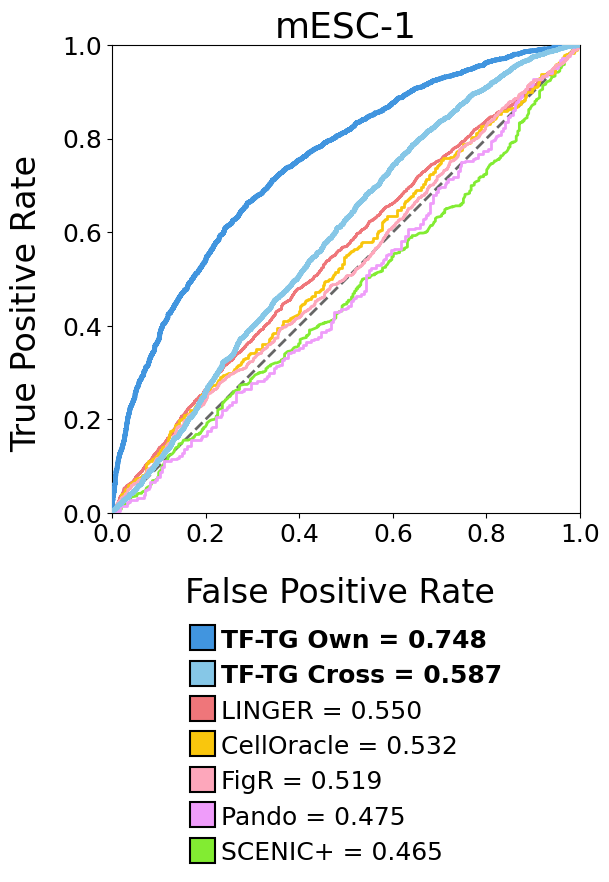

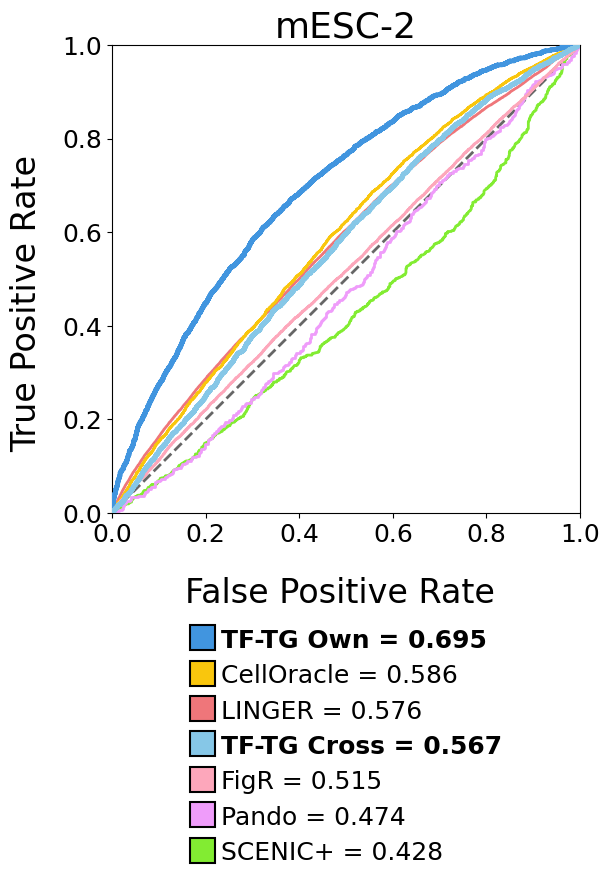

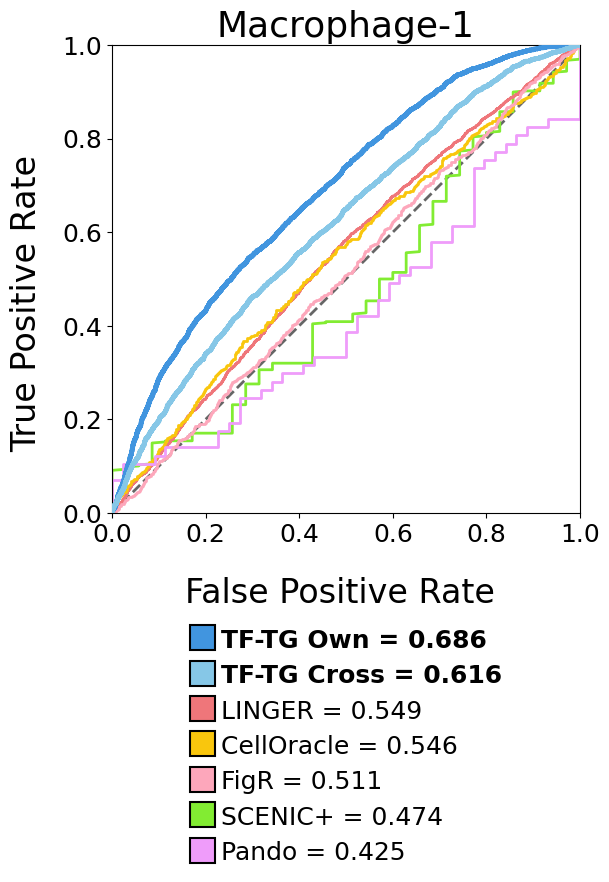

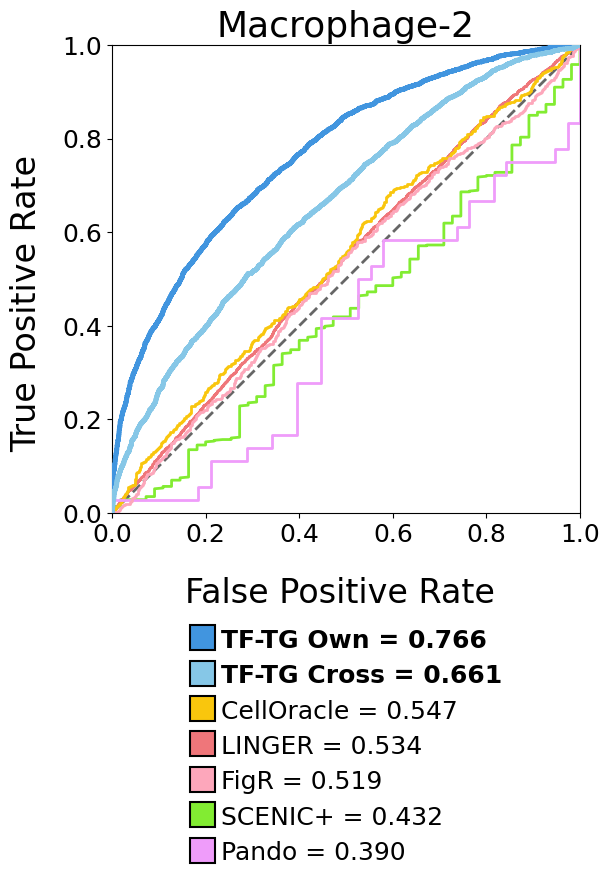

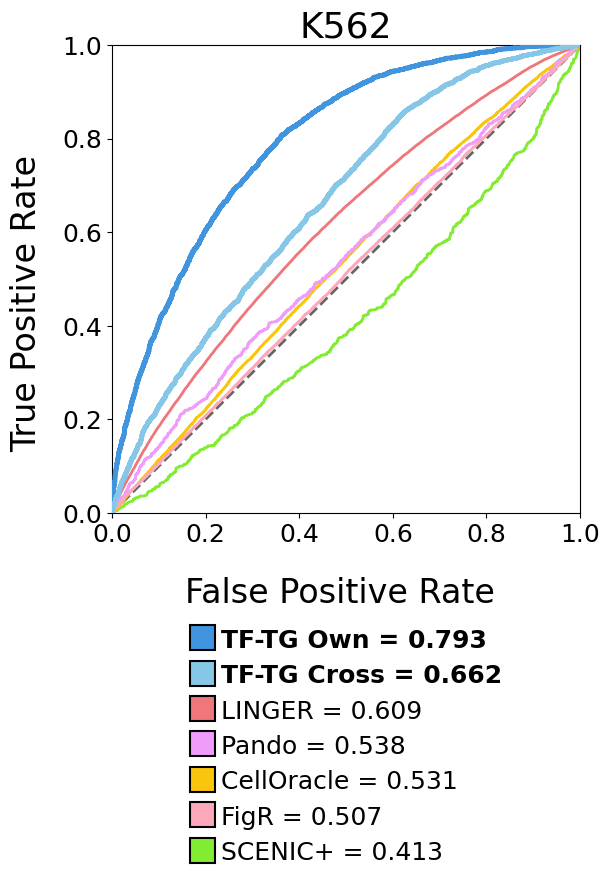

WARNING - Skipping ROC for hepatocytes_1 / Pando: only one class present.


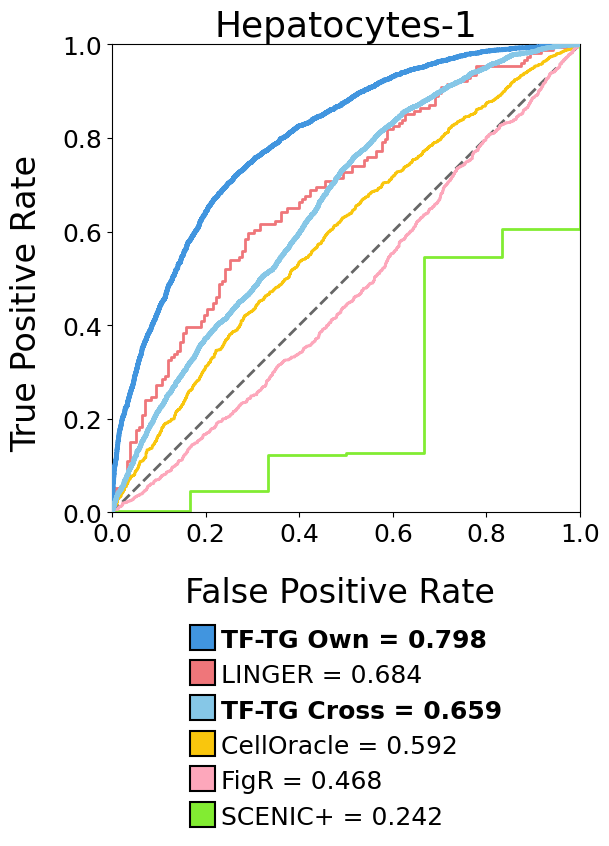

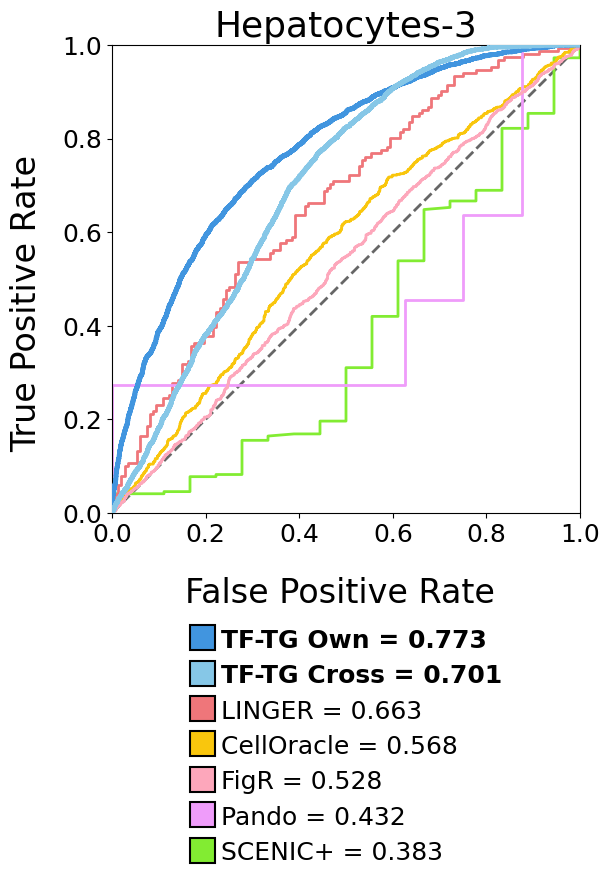

In [59]:
for sample_name in sample_order:
    if sample_name not in standardized_method_dfs:
        continue

    fig, sample_auroc_df = plot_sample_roc_curves(
        sample_name=sample_name,
        standardized_method_dfs=standardized_method_dfs,
        gt_by_sample_dict=gt_by_sample_dict,
        method_color_dict=method_color_dict,
        sample_rename_map=sample_rename_map,
        roc_plot_dir=roc_plot_dir,
        method_display_name_map=method_display_name_map,
        figsize=(6, 6),
    )

    plt.show()

### PRC Curves

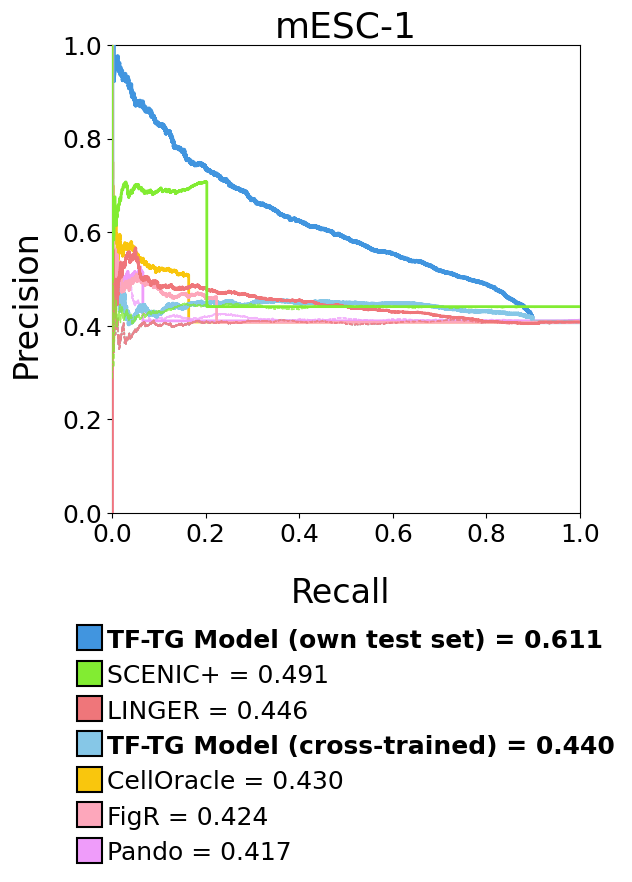

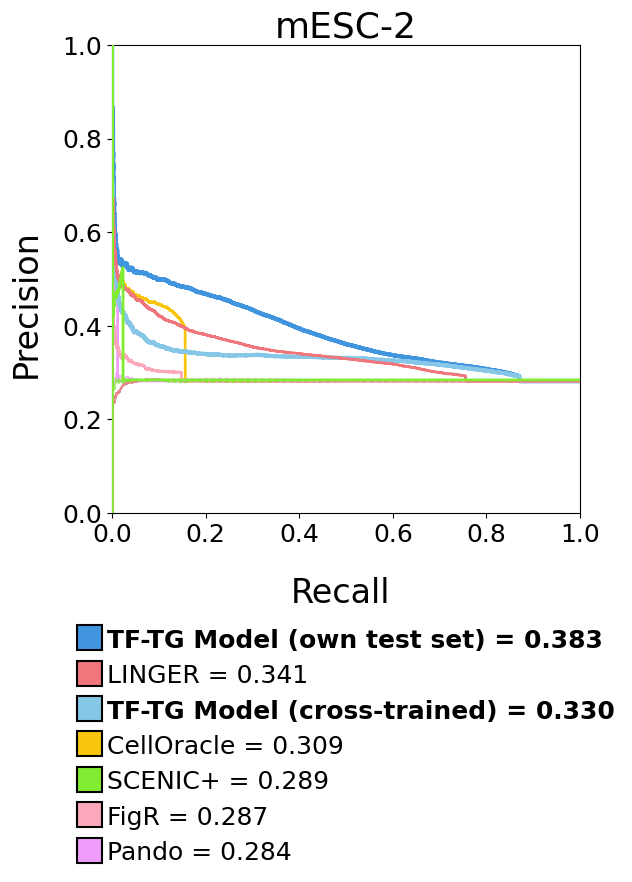

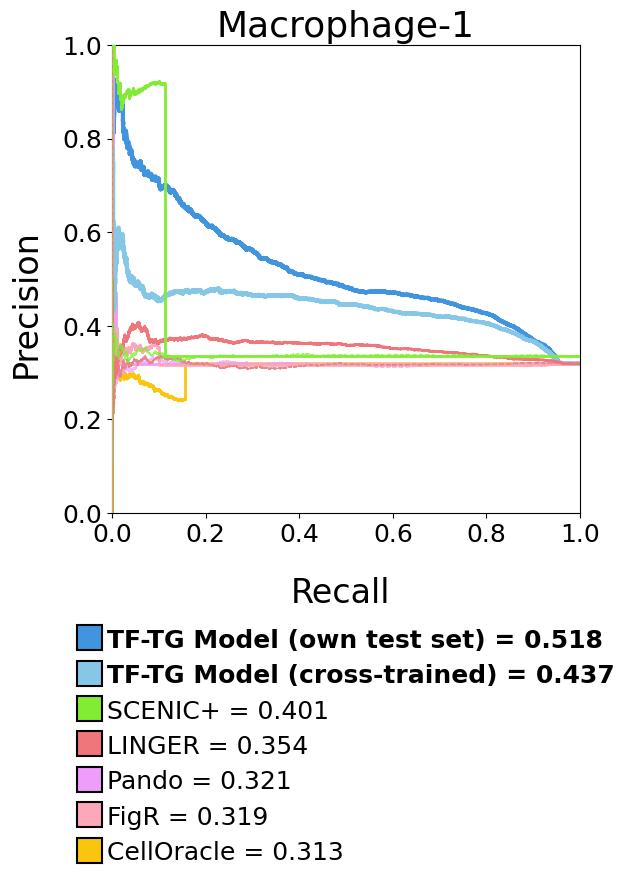

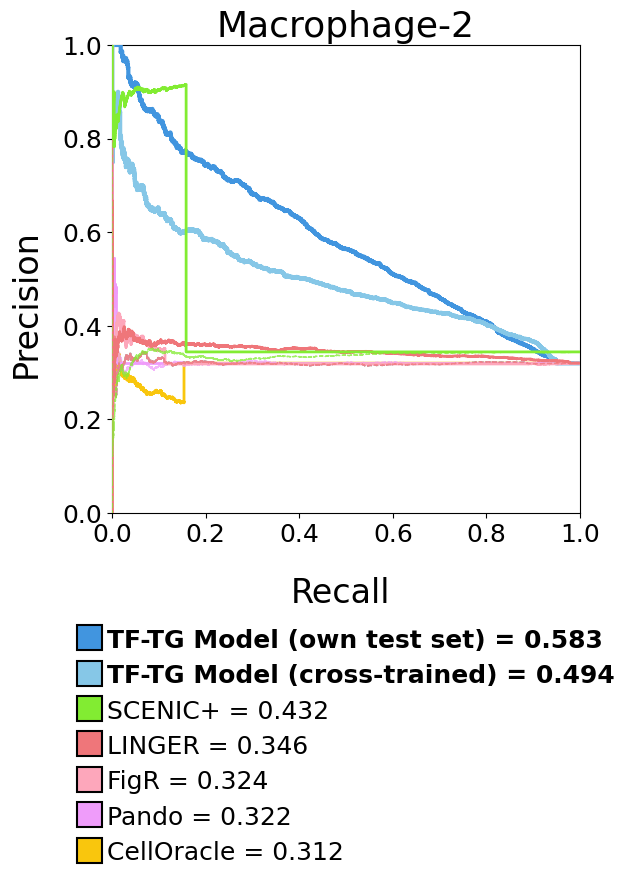

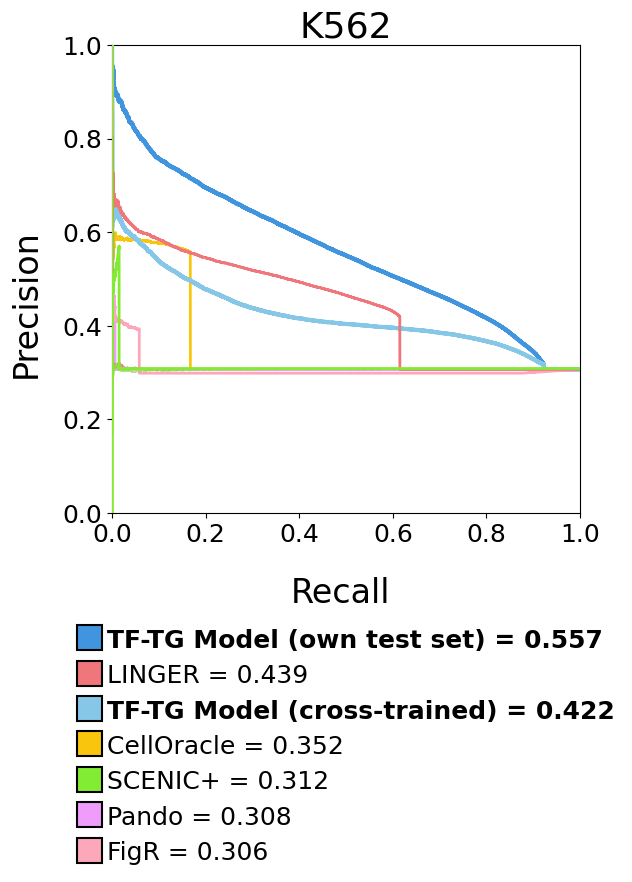

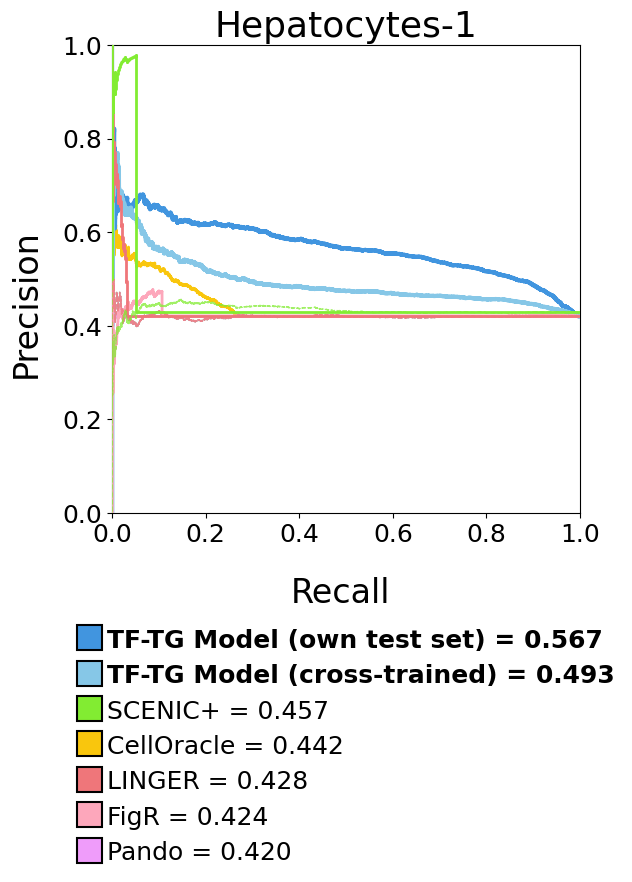

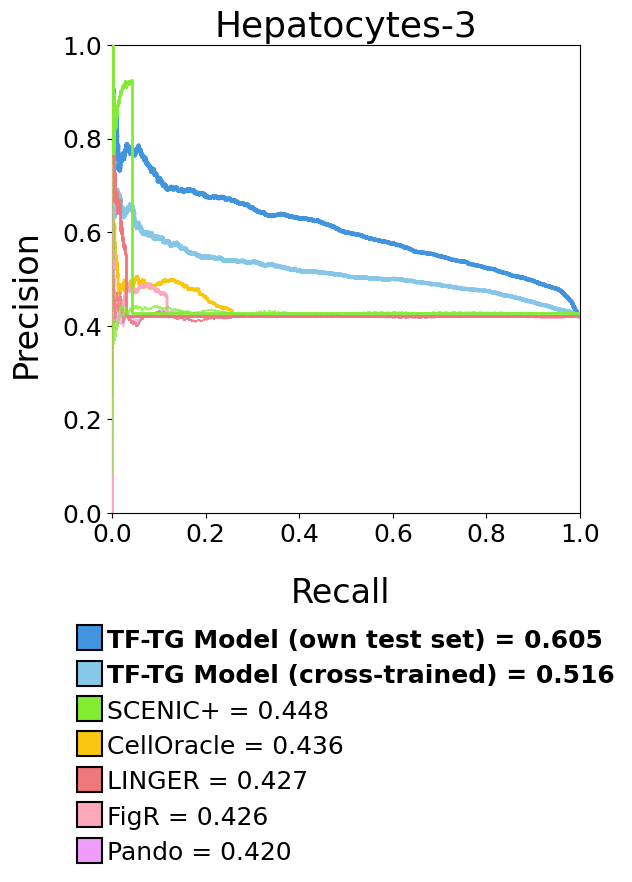

In [63]:
for sample_name in sample_order:
    if sample_name not in auprc_all_method_dfs:
        continue
    
    fig, sample_auprc_df = plot_sample_prc_curves(
        sample_name=sample_name,
        auprc_all_method_dfs=auprc_all_method_dfs,
        method_color_dict=method_color_dict,
        sample_rename_map=sample_rename_map,
    )
    
    plt.show()

### Rank Plots

In [34]:
def metric_df_to_rank_df(
    full_metric_df,
    metric_col,
    experiment_col="sample_name",
    method_col="method_name",
    higher_is_better=True,
):
    metric_df = (
        full_metric_df
        [[experiment_col, method_col, metric_col]]
        .dropna()
        .copy()
    )

    metric_df = (
        metric_df
        .groupby([experiment_col, method_col], as_index=False)
        .agg(metric_value=(metric_col, "median"))
    )

    metric_df = metric_df.rename(
        columns={
            experiment_col: "experiment",
            method_col: "method",
        }
    )

    metric_df["rank"] = (
        metric_df
        .groupby("experiment")["metric_value"]
        .rank(
            method="min",
            ascending=not higher_is_better,
        )
        .astype(int)
    )

    all_ranks_df = metric_df.sort_values(["experiment", "rank"]).copy()

    rank_df = (
        all_ranks_df
        .groupby("method", as_index=False)
        .agg(
            avg_rank=("rank", "mean"),
            median_rank=("rank", "median"),
            mean_metric=("metric_value", "mean"),
        )
        .sort_values(["avg_rank", "median_rank"], ascending=True)
        .reset_index(drop=True)
    )

    return all_ranks_df, rank_df

def avg_rank_by_method_plot(
    avg_rank_df,
    method_color_dict,
    title,
    sample_rename_map=None,
    figsize=(7, 4),
):
    if sample_rename_map is None:
        sample_rename_map = {}

    plot_df = avg_rank_df.copy()
    order = plot_df["method"].tolist()

    fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(
        data=plot_df,
        x="method",
        y="avg_rank",
        order=order,
        hue="method",
        palette=method_color_dict,
        dodge=False,
        legend=False,
        ax=ax,
    )

    new_labels = []
    for tick in ax.get_xticklabels():
        original = tick.get_text()
        new = sample_rename_map.get(original, original)
        new_labels.append(new)

        if original in TFTG_MODEL_METHODS:
            tick.set_color(method_color_dict.get(original, "black"))
            tick.set_fontweight("bold")
        else:
            tick.set_color("black")
            tick.set_fontweight("normal")

    ax.set_xticklabels(new_labels, rotation=45, ha="right")
    ax.set_ylabel("Average Rank")
    ax.set_xlabel("")
    ax.set_title(title, fontsize=16)

    ax.set_ylim(0, max(plot_df["avg_rank"].max() + 0.5, 1.5))

    plt.tight_layout()
    return fig

def experiment_by_method_rank_heatmap(
    all_ranks_df,
    rank_df,
    method_color_dict,
    title=None,
    sample_order=None,
    sample_rename_map=None,
    figsize=(7, 4),
    square_cells=True,
):
    if sample_rename_map is None:
        sample_rename_map = {}

    rank_heatmap_df = all_ranks_df.pivot(
        index="experiment",
        columns="method",
        values="rank",
    )

    method_order = rank_df["method"].tolist()

    if sample_order is None:
        sample_order = rank_heatmap_df.index.tolist()

    sample_order = [
        exp for exp in sample_order
        if exp in rank_heatmap_df.index
    ]

    rank_heatmap_df = rank_heatmap_df.reindex(
        index=sample_order,
        columns=method_order,
    )

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        rank_heatmap_df,
        annot=True,
        fmt=".0f",
        cmap="viridis_r",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Rank"},
        annot_kws={"size": 11, "fontweight": "bold"},
        ax=ax,
    )

    if square_cells:
        ax.set_aspect("equal")

    new_x_labels = []
    for tick in ax.get_xticklabels():
        original = tick.get_text()
        new = sample_rename_map.get(original, original)
        new_x_labels.append(new)

        if original in TFTG_MODEL_METHODS:
            tick.set_color(method_color_dict.get(original, "black"))
            tick.set_fontweight("bold")
        else:
            tick.set_color("black")
            tick.set_fontweight("normal")

    new_y_labels = []
    for tick in ax.get_yticklabels():
        original = tick.get_text()
        new = sample_rename_map.get(original, original)
        new_y_labels.append(new)

    ax.set_xticklabels(new_x_labels, rotation=45, ha="right", fontsize=11)
    ax.set_yticklabels(new_y_labels, rotation=0, fontsize=11)

    ax.set_title(title or "Method Rank by Test Set", fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.tight_layout()
    return fig


/tmp/ipykernel_201810/1942502307.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right")


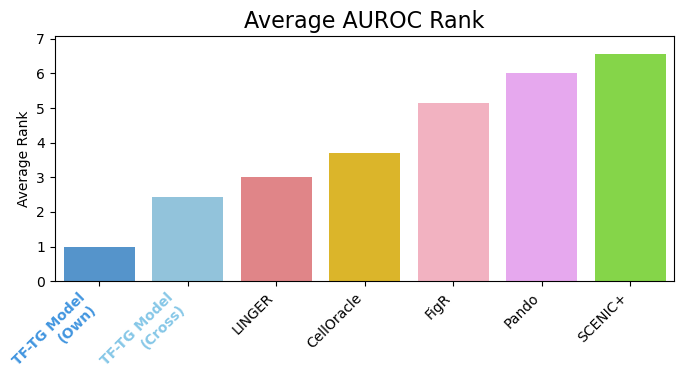

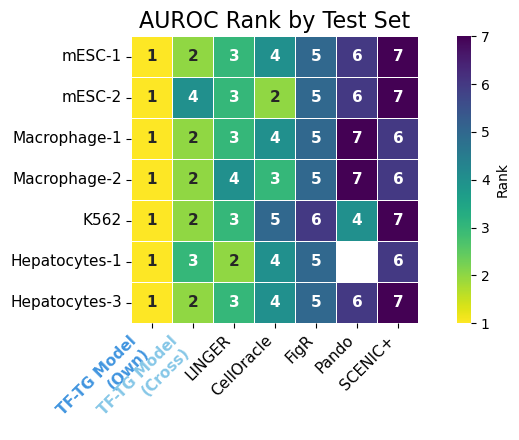

/tmp/ipykernel_201810/1942502307.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right")


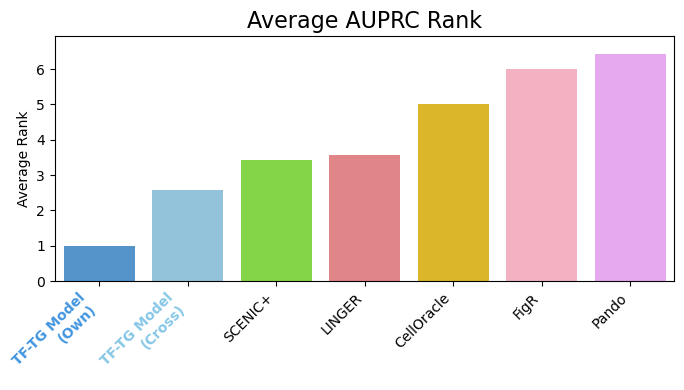

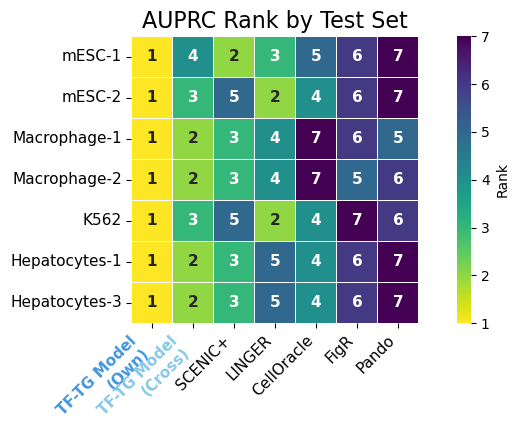

/tmp/ipykernel_201810/1942502307.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right")


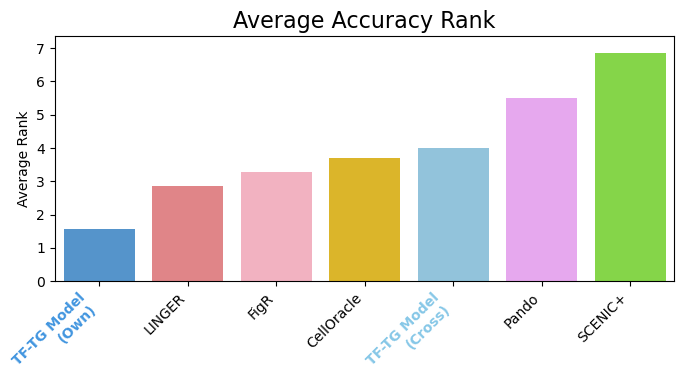

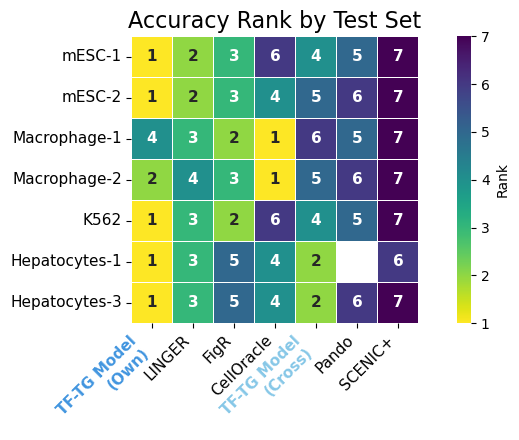

/tmp/ipykernel_201810/1942502307.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right")


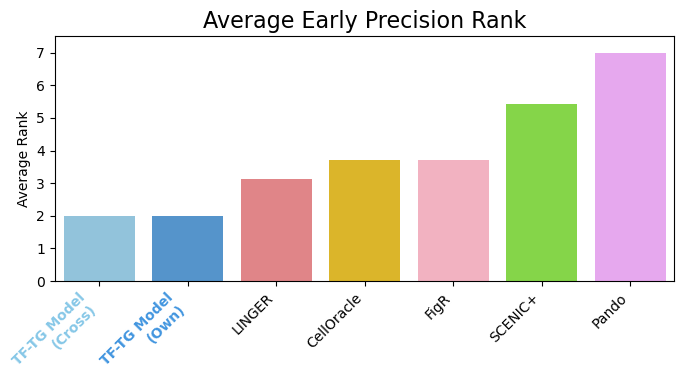

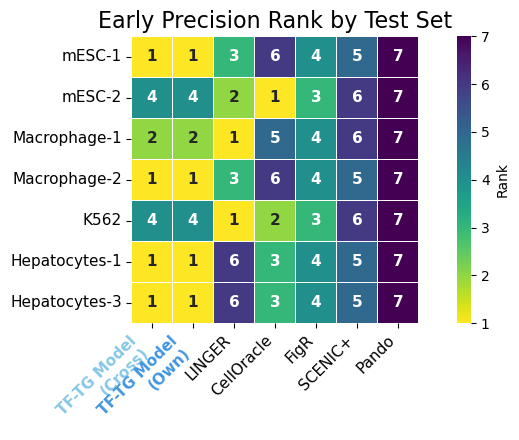

/tmp/ipykernel_201810/1942502307.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right")


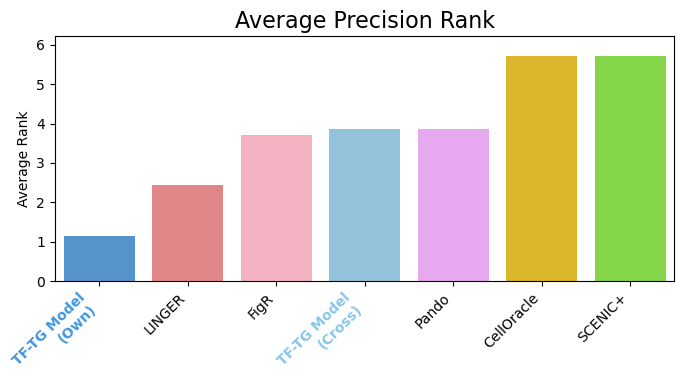

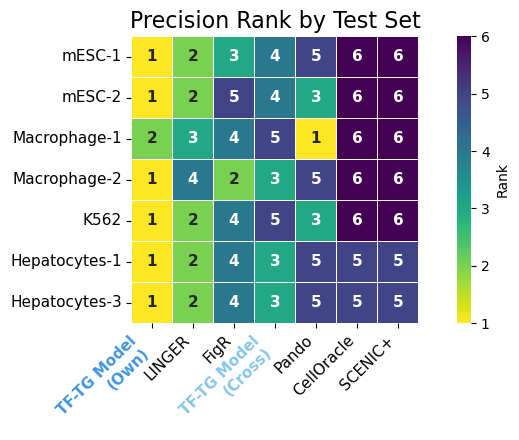

/tmp/ipykernel_201810/1942502307.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right")


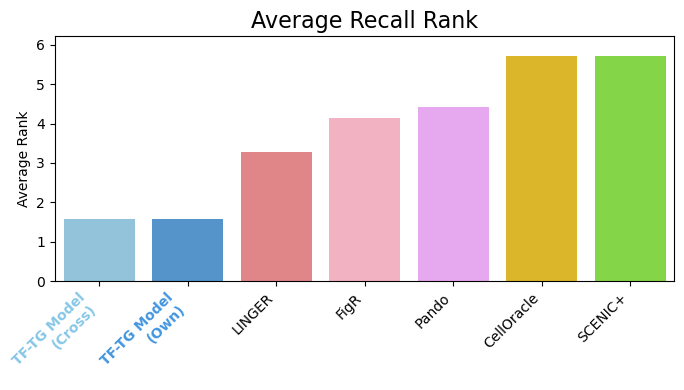

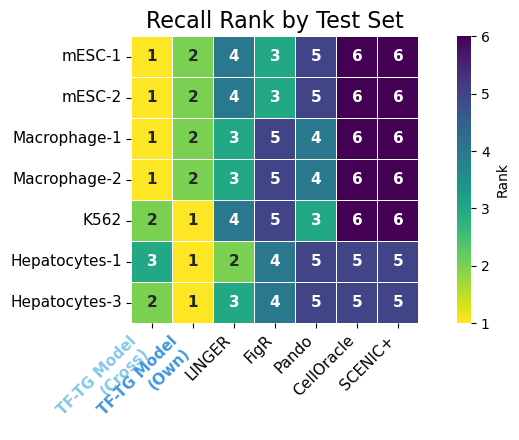

/tmp/ipykernel_201810/1942502307.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right")


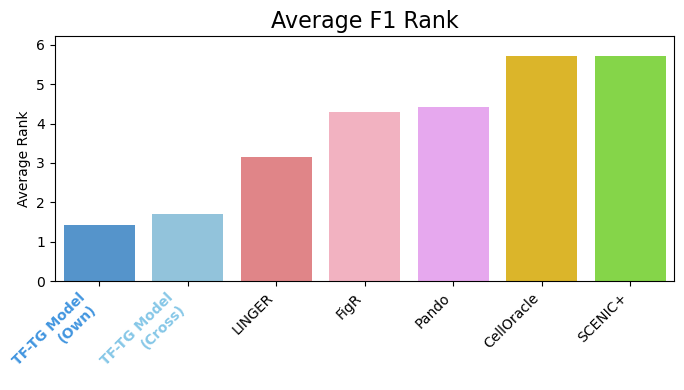

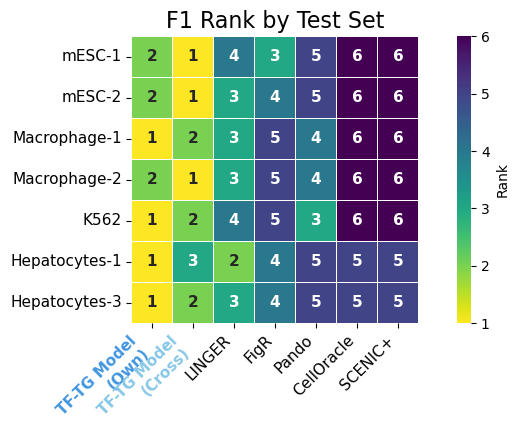

In [36]:
metric_name_map = {
    "auroc": "AUROC",
    "auprc": "AUPRC",
    "accuracy": "Accuracy",
    "early_precision": "Early Precision",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
}

metrics = [
    "auroc",
    "auprc",
    "accuracy",
    "early_precision",
    "precision",
    "recall",
    "f1",
]

for metric_col in metrics:
    metric_label = metric_name_map.get(
        metric_col,
        metric_col.replace("_", " ").title(),
    )

    all_ranks_df, rank_df = metric_df_to_rank_df(
        full_metric_df=full_metric_df,
        metric_col=metric_col,
        experiment_col="sample_name",
        method_col="method_name",
        higher_is_better=True,
    )

    safe_metric_name = metric_col.lower().replace(" ", "_")

    # Full method average-rank barplot
    full_avg_rank_fig = avg_rank_by_method_plot(
        rank_df,
        method_color_dict=method_color_dict,
        title=f"Average {metric_label} Rank",
        sample_rename_map=sample_rename_map,
        figsize=(7, 4),
    )

    full_avg_rank_fig.savefig(
        rank_plot_dir / f"average_{safe_metric_name}_rank_all_methods.png",
        dpi=300,
        bbox_inches="tight",
    )

    # Full method rank heatmap
    full_rank_heatmap_fig = experiment_by_method_rank_heatmap(
        all_ranks_df,
        rank_df,
        method_color_dict=method_color_dict,
        sample_order=sample_order,
        sample_rename_map=sample_rename_map,
        title=f"{metric_label} Rank by Test Set",
        figsize=(8, 4.5),
    )

    full_rank_heatmap_fig.savefig(
        rank_plot_dir / f"{safe_metric_name}_rank_heatmap_all_methods.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

---

## GIF of True/False histogram across training

In [ ]:
model_cell_type = "Macrophage"
model_training_sample = "buffer_3"

chkpt_dir = utils.find_latest_checkpoint(model_cell_type, model_training_sample).parent
print(f"Using checkpoint directory: {chkpt_dir.name}")

chkpt_files = list(chkpt_dir.glob("epoch=*-val_auroc=*-val_loss=*.ckpt"))
if not chkpt_files:
    logging.warning(f"No checkpoint files found for {model_training_sample} in {chkpt_dir.name}")

chkpt_files.sort(key=lambda f: int(f.stem.split("-")[0].split("=")[1]), reverse=False)
chkpt_nums = [int(f.stem.split("-")[0].split("=")[1]) for f in chkpt_files]

# only plot every 10 epochs
chkpt_files = [f for f in chkpt_files if int(f.stem.split("-")[0].split("=")[1]) % 10 == 0]
print(f"Found {len(chkpt_files)} checkpoint files with epochs: {chkpt_nums[:2]} ... {chkpt_nums[-2:]}")

per_epoch_plot_data = {}
all_comparison_df_list = []
subset_size = 3000
for chkpt_file in tqdm(chkpt_files, desc="Evaluating Checkpoints", ncols=100):
    dataset_split_type = "val"
    
    epoch_num = int(chkpt_file.stem.split("-")[0].split("=")[1])
    
    tf_tg_model_checkpoints[model_cell_type][model_training_sample] = chkpt_file
    
    comparison_result = run_prediction_vs_test_set(
        tf_tg_model_checkpoints=tf_tg_model_checkpoints,
        model_cell_type=model_cell_type,
        model_training_sample=model_training_sample,
        test_set_cell_type=model_cell_type,
        evaluation_sample=model_training_sample,
        dataset_split_type=dataset_split_type,
        subset_size=subset_size,
        show_progress_bar=False,
    )
        
    metric_df = comparison_result["metric_df"]
    metric_df["epoch"] = epoch_num
    
    plot_data = comparison_result["plot_data"]
    
    all_labels_flat = plot_data[0]
    all_scores_flat = plot_data[1]
    
    title = f"{model_cell_type} {model_training_sample}\nEpoch {epoch_num}"
    
    per_epoch_plot_data[title] = (all_labels_flat, all_scores_flat)
    
    all_comparison_df_list.append(metric_df)
    
all_epoch_df = pd.concat(all_comparison_df_list, ignore_index=True)


plot_dir = PROJECT_DIR / "plots" / "histogram_per_epoch" / f"{model_cell_type}_{model_training_sample}"
plot_dir.mkdir(parents=True, exist_ok=True)
(plot_dir / "epoch_figs").mkdir(parents=True, exist_ok=True)

for title in tqdm(per_epoch_plot_data.keys(), desc="Plotting Histograms", ncols=100):        
    labels = per_epoch_plot_data[title][0]
    scores = per_epoch_plot_data[title][1]
    
    epoch = int(title.split("\nEpoch ")[1])

    histogram_fig = plotting_utils.plot_score_histograms(
        labels=labels,
        scores=scores,
        n_bins=50,
        y_log=False,
        panel_kind="hist",
        density=False,
        title = title,
        y_lim=(0, 100),
        x_lim=(0, 1)
    )

    histogram_fig.savefig(plot_dir / "epoch_figs" / f"epoch_{epoch}.png")
    plt.close(histogram_fig)
    
# Combine all histogram plots into a GIF in epoch order
import imageio.v3 as iio
gif_path = plot_dir / f"{model_cell_type}_{model_training_sample}_histograms.gif"

filenames = sorted(plot_dir.glob("epoch_figs/epoch_*.png"), key=lambda f: int(f.stem.split("_")[1]))
images = [iio.imread(str(f)) for f in filenames]

default_duration = 200
# The lagging
lag = 2000
# Pause the GIF by extending the duration of the last frame
duration = [default_duration] * (len(images)-1) + [lag]
iio.imwrite(gif_path, images, duration=duration, loop=0)

INFO - Latest checkpoint for Macrophage buffer_3: Job 3696133 Epoch 126


Using checkpoint directory: tf_tg_train_buffer_3_3696133
Found 13 checkpoint files with epochs: [0, 1] ... [125, 126]


Plotting Histograms: 100%|██████████████████████████████████████████| 13/13 [00:02<00:00,  4.90it/s]
